In [5]:
import pandas as pd
import numpy as np
df = pd.read_csv(r"C:\Users\Liam\Desktop\frames_40ms_features_robust_clean.csv")
# ===== 1) Filter by minimum frames per speaker =====
MIN_FRAMES = 50  # you can change to 30/60 for sensitivity tests
counts = df['speakerID'].value_counts()
valid_speakers = counts[counts >= MIN_FRAMES].index
df_min = df[df['speakerID'].isin(valid_speakers)].copy()

print(f"Total frames (raw): {len(df)}  | Speakers: {df['speakerID'].nunique()}")
print(f"After MIN_FRAMES >= {MIN_FRAMES}: frames={len(df_min)} | speakers={df_min['speakerID'].nunique()}")

# OPTIONAL: sanity check distribution of counts after filtering
post_counts = df_min['speakerID'].value_counts()
print("Post-filter frame count per speaker (summary):")
print(post_counts.describe())

Total frames (raw): 38187  | Speakers: 305
After MIN_FRAMES >= 50: frames=36569 | speakers=138
Post-filter frame count per speaker (summary):
count     138.000000
mean      264.992754
std       851.863123
min        50.000000
25%        68.000000
50%        82.000000
75%       115.500000
max      8235.000000
Name: count, dtype: float64


In [7]:
# ===== 2) Speaker-level mean/cov/total variance =====
speaker_stats = {}
feat_cols = [f"Delta_n{i}_Hz" for i in range(1, 7)]

for sp, data in df_min.groupby('speakerID'):
    vals = data[feat_cols].dropna().values
    mean_vec = vals.mean(axis=0)
    cov_matrix = np.cov(vals, rowvar=False)  # guaranteed stable with n>=MIN_FRAMES
    speaker_stats[sp] = {
        "mean": mean_vec,
        "cov": cov_matrix,
        "total_var": float(np.trace(cov_matrix))
    }

total_variances = np.array([s["total_var"] for s in speaker_stats.values()])
print(f"Median total variance: {np.median(total_variances):.2f}")
print(f"90th percentile: {np.quantile(total_variances, 0.9):.2f}")
print(f"Max total variance: {np.max(total_variances):.2f}")



Median total variance: 448.06
90th percentile: 757.96
Max total variance: 1498.50


In [9]:
# ===== 3) High-variance set & balanced sampling =====
high_var_threshold = np.quantile(total_variances, 0.9)
high_speakers = [sp for sp, st in speaker_stats.items() if st["total_var"] > high_var_threshold]

MAX_FRAMES_PER_SPK = 100
balanced_samples = []
rng = np.random.default_rng(42)
for sp, data in df_min.groupby('speakerID'):
    if len(data) > MAX_FRAMES_PER_SPK:
        # sample WITHOUT replacement to avoid duplication
        idx = rng.choice(data.index, size=MAX_FRAMES_PER_SPK, replace=False)
        balanced_samples.append(data.loc[idx])
    else:
        balanced_samples.append(data)
balanced_df = pd.concat(balanced_samples, ignore_index=True)

print(f"Balanced frames: {len(balanced_df)} | Speakers: {balanced_df['speakerID'].nunique()}")


Balanced frames: 11206 | Speakers: 138


In [11]:
import numpy as np

# Calculate the six-dimensional offset mean vector and covariance matrix for each speaker, as well as the covariance trace (total variance).
speaker_stats = {}
for sp, data in df.groupby('speakerID'):
    vals = data[[f"Delta_n{i}_Hz" for i in range(1,7)]].dropna().values
    if vals.shape[0] <= 1:
        mean_vec = vals.mean(axis=0) if vals.size > 0 else np.zeros(6)
        cov_matrix = np.zeros((6,6))
    else:
        mean_vec = vals.mean(axis=0)
        cov_matrix = np.cov(vals, rowvar=False)
    total_variance = cov_matrix.trace()  
    speaker_stats[sp] = {"mean": mean_vec, "cov": cov_matrix, "total_var": total_variance}


In [13]:
from numpy.linalg import inv

global_mean = df_min[feat_cols].mean().values
global_cov = np.cov(df_min[feat_cols].dropna().values, rowvar=False)
global_cov_inv = inv(global_cov)

mahalanobis_dist = {}
for sp, st in speaker_stats.items():
    diff = st["mean"] - global_mean
    mahalanobis_dist[sp] = float(np.sqrt(diff.T @ global_cov_inv @ diff))

top10 = sorted(mahalanobis_dist.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top-10 speakers by Mahalanobis distance (after min-frames filter):")
print(top10)



Top-10 speakers by Mahalanobis distance (after min-frames filter):
[('aa000009', 3.7567305772376614), ('bb000010', 3.7567305772376614), ('18BTQ623', 2.7518745814830914), ('bb000033', 1.3928979231462022), ('aa000075', 1.2583409631515992), ('aa000001', 1.226183551682391), ('bb000002', 1.226183551682391), ('8D2JUFXG', 1.1365218482681756), ('aa000044', 1.0301160755177712), ('bb000045', 1.0301160755177712)]


Explained variance ratio by PC1 and PC2: [0.51424992 0.24521517]


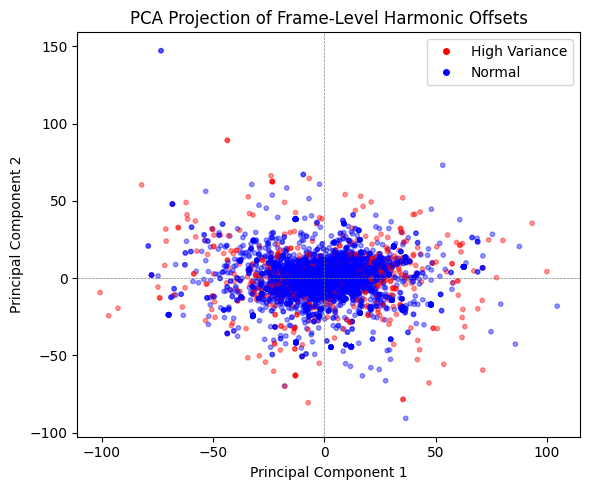

In [15]:
#this mothod may have the problem of double-dipping/data leakage, later we have better method

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Identify high-variance speakers (top 10% by total variance)
high_var_threshold = np.quantile(total_variances, 0.9)
high_speakers = [sp for sp, stats in speaker_stats.items() if stats["total_var"] > high_var_threshold]

# Extract 6-dim delta_n features and apply PCA
features = balanced_df[[f"Delta_n{i}_Hz" for i in range(1, 7)]].dropna().values
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features)
print("Explained variance ratio by PC1 and PC2:", pca.explained_variance_ratio_)

# Assign label based on whether the speaker is in the high-variance group
labels = balanced_df['speakerID'].apply(lambda sp: 'HighVar' if sp in high_speakers else 'Normal')
colors = labels.map({'HighVar': 'red', 'Normal': 'blue'}).values

# Plot the 2D PCA projection
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.4, s=10)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Frame-Level Harmonic Offsets')
# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='High Variance', markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Normal', markerfacecolor='blue', markersize=6)
]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()



Group counts:
 Group
Normal           9996
High Variance    1210
Name: count, dtype: int64


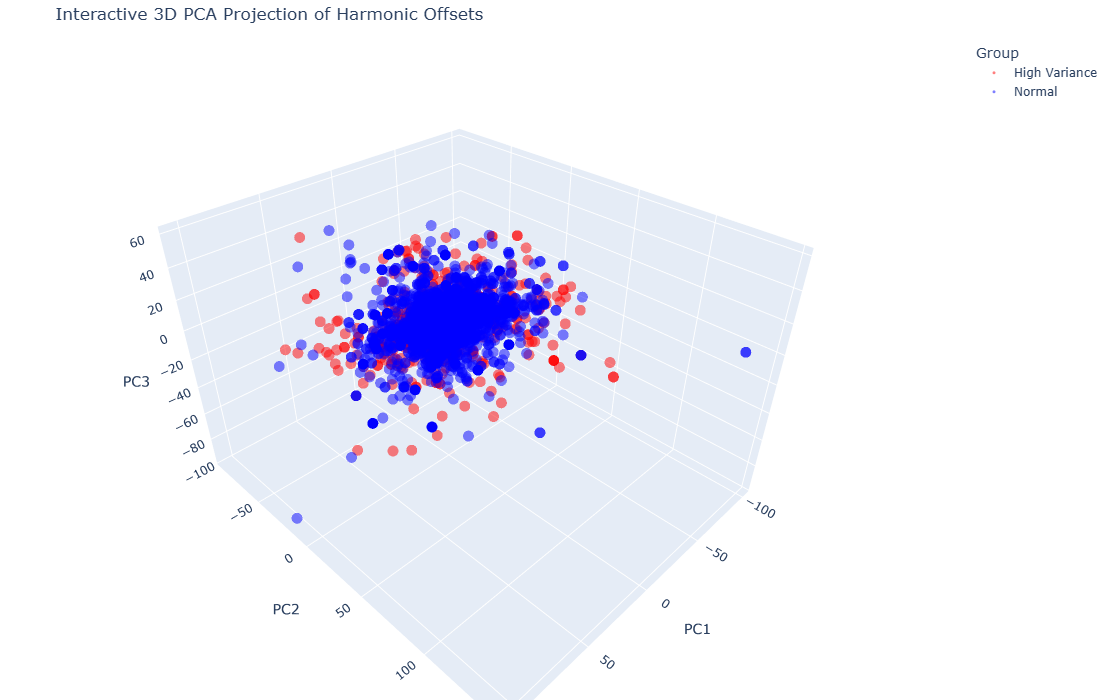

In [61]:
import plotly.express as px
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd


HIGH_LABEL = "High Variance"
NORM_LABEL = "Normal"

# 3D PCA 
feat_cols = [f"Delta_n{i}_Hz" for i in range(1, 7)]
features = balanced_df[feat_cols].dropna().values

pca3d = PCA(n_components=3)
X_pca_3d = pca3d.fit_transform(features)

#  Boolean type to text
is_high = balanced_df["speakerID"].isin(high_speakers).values
group_vals = np.where(is_high, HIGH_LABEL, NORM_LABEL)

pca_df = pd.DataFrame(X_pca_3d, columns=["PC1", "PC2", "PC3"])
pca_df["SpeakerID"] = balanced_df["speakerID"].astype(str).values
pca_df["Group"] = pd.Series(group_vals).astype(str).str.strip()


print("Group counts:\n", pca_df["Group"].value_counts(dropna=False))


color_map = {HIGH_LABEL: "red", NORM_LABEL: "blue"}
category_order = { "Group": [HIGH_LABEL, NORM_LABEL] }

fig = px.scatter_3d(
    pca_df,
    x="PC1", y="PC2", z="PC3",
    color="Group",
    category_orders=category_order,        
    color_discrete_map=color_map,          
    hover_data=["SpeakerID"],
    opacity=0.5
)


fig.update_traces(marker=dict(size=3))
fig.update_layout(
    scene=dict(xaxis_title="PC1", yaxis_title="PC2", zaxis_title="PC3"),
    title="Interactive 3D PCA Projection of Harmonic Offsets",
    width=1000, height=700, margin=dict(l=0, r=0, b=0, t=40)
)
fig.show()



In [63]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

feat_cols = [f"Delta_n{i}_Hz" for i in range(1, 7)]

# Speaker-level aggregation (based on filtered df_min)
spk = (df_min
       .groupby('speakerID')[feat_cols]
       .mean()
       .reset_index())
spk['Group'] = np.where(spk['speakerID'].isin(high_speakers), 'High', 'Normal')

print("Speakers: ", spk['Group'].value_counts().to_dict())

# Univariate Welch t-test (for each Delta_n dimension)
def hedges_g(a, b):
    na, nb = len(a), len(b)
    sa2, sb2 = a.var(ddof=1), b.var(ddof=1)
    sp2 = ((na-1)*sa2 + (nb-1)*sb2) / (na + nb - 2)
    d = (a.mean() - b.mean()) / np.sqrt(sp2)
    J = 1 - 3/(4*(na+nb)-9)  # small-sample correction
    return d * J

rows = []
for col in feat_cols:
    a = spk.loc[spk['Group']=='High', col].dropna()
    b = spk.loc[spk['Group']=='Normal', col].dropna()
    t, p = stats.ttest_ind(a, b, equal_var=False)
    g = hedges_g(a, b)
    rows.append([col, a.mean(), b.mean(), g, t, p, len(a), len(b)])

res = pd.DataFrame(rows, columns=[
    'feature','mean_high','mean_normal','hedges_g','t','p','n_high','n_normal'
])
res['p_fdr'] = multipletests(res['p'], method='fdr_bh')[1]
res['p_bonf'] = multipletests(res['p'], method='bonferroni')[1]
print(res.sort_values('p'))

#  multi Hotelling T²
X = spk.loc[spk['Group']=='High', feat_cols].values
Y = spk.loc[spk['Group']=='Normal', feat_cols].values

def hotelling_2sample(X, Y):
    n1, p = X.shape
    n2, _ = Y.shape
    mean1, mean2 = X.mean(0), Y.mean(0)
    S1, S2 = np.cov(X, rowvar=False), np.cov(Y, rowvar=False)
    Spooled = ((n1-1)*S1 + (n2-1)*S2) / (n1 + n2 - 2)
    diff = mean1 - mean2
    T2 = (n1*n2)/(n1+n2) * diff.T @ np.linalg.inv(Spooled) @ diff
    df1 = p
    df2 = n1 + n2 - p - 1
    F = T2 * (df2 / (df1 * (n1 + n2 - 2)))
    pval = 1 - stats.f.cdf(F, df1, df2)
    return T2, F, pval, df1, df2

T2, Fv, p_hot, df1, df2 = hotelling_2sample(X, Y)
print(f"Hotelling T^2={T2:.2f}, F={Fv:.2f}, p={p_hot:.3e} (df1={df1}, df2={df2})")


Speakers:  {'Normal': 124, 'High': 14}
       feature  mean_high  mean_normal  hedges_g         t         p  n_high  \
3  Delta_n4_Hz   1.289408     0.270517  0.739364  2.314307  0.035036      14   
1  Delta_n2_Hz   0.992406     0.526937  0.973396  2.313216  0.036360      14   
0  Delta_n1_Hz   0.696103     0.511871  0.604044  1.946620  0.070098      14   
4  Delta_n5_Hz   1.335056     0.797515  0.366256  0.804259  0.434843      14   
2  Delta_n3_Hz   0.722637     0.497167  0.258527  0.532914  0.602632      14   
5  Delta_n6_Hz   1.482410     1.638118 -0.062537 -0.219001  0.829429      14   

   n_normal     p_fdr    p_bonf  
3       124  0.109081  0.210217  
1       124  0.109081  0.218161  
0       124  0.140196  0.420589  
4       124  0.652264  1.000000  
2       124  0.723159  1.000000  
5       124  0.829429  1.000000  
Hotelling T^2=23.85, F=3.83, p=1.503e-03 (df1=6, df2=131)


In [65]:
import numpy as np, pandas as pd
from scipy import stats

feat_cols = [f"Delta_n{i}_Hz" for i in range(1, 7)]

# 基于已过滤后的 df_min
spk_var = (df_min.groupby('speakerID')[feat_cols].var().reset_index())
spk_var['Group'] = np.where(spk_var['speakerID'].isin(high_speakers), 'High', 'Normal')

# 用更稳健的检验（Mann–Whitney 或 Brown–Forsythe/Levene center='median'）
rows = []
for col in feat_cols:
    a = spk_var.loc[spk_var['Group']=='High', col].dropna()
    b = spk_var.loc[spk_var['Group']=='Normal', col].dropna()
    # 非参数：方差分布的秩和对比（更稳健）
    U, p_u = stats.mannwhitneyu(a, b, alternative='two-sided')
    # 方差同质性：Levene（对非正态更稳健，center='median'）
    W, p_lev = stats.levene(a, b, center='median')
    rows.append([col, a.median(), b.median(), U, p_u, W, p_lev, len(a), len(b)])

var_res = pd.DataFrame(rows, columns=[
    'feature','median_var_high','median_var_norm','U','p_mannwhitney','W_levene','p_levene','n_high','n_norm'
]).sort_values('p_levene')
print(var_res)


       feature  median_var_high  median_var_norm       U  p_mannwhitney  \
1  Delta_n2_Hz        27.501176         9.826800  1561.0   1.042373e-06   
2  Delta_n3_Hz        64.913347        23.236206  1612.0   1.578886e-07   
0  Delta_n1_Hz         8.793583         2.587796  1457.0   3.323818e-05   
5  Delta_n6_Hz       444.279406       171.813207  1705.0   3.658343e-09   
4  Delta_n5_Hz       250.928892        96.394927  1714.0   2.485417e-09   
3  Delta_n4_Hz       152.415864        56.812308  1717.0   2.183022e-09   

    W_levene  p_levene  n_high  n_norm  
1  20.480001  0.000013      14     124  
2   5.049355  0.026246      14     124  
0   2.250331  0.135904      14     124  
5   0.639960  0.425120      14     124  
4   0.028576  0.866013      14     124  
3   0.014956  0.902847      14     124  


In [67]:
import numpy as np
from numpy.linalg import slogdet, inv
from scipy import stats

def box_m_test(groups):
    """
    groups: list of 2D arrays, each shape (n_i, p), Compare whether the covariances of multiple groups are the same.
    """
    ks = [g.shape[0] for g in groups]
    p = groups[0].shape[1]
    covs = [np.cov(g, rowvar=False) for g in groups]
    Ns = sum(ks)
    # pooled covariance
    Sp = sum([(k-1)*cov for k, cov in zip(ks, covs)]) / (Ns - len(groups))
    # log-determinants
    logdet_Sp = slogdet(Sp)[1]
    logdet_sum = sum([(k-1)*slogdet(cov)[1] for k, cov in zip(ks, covs)])
    M = (Ns - len(groups)) * logdet_Sp - logdet_sum

    # correction factor (approx to Chi-square)
    c = ( (sum([1/(k-1) for k in ks]) - 1/(Ns - len(groups))) *
          (2*p**2 + 3*p - 1) / (6*(p+1)*(len(groups)-1)) )
    chi2 = M * (1 - c)
    df = (len(groups)-1) * p*(p+1)/2
    pval = 1 - stats.chi2.cdf(chi2, df)
    return M, chi2, df, pval

X_high = balanced_df[balanced_df['speakerID'].isin(high_speakers)][feat_cols].dropna().values
X_norm = balanced_df[~balanced_df['speakerID'].isin(high_speakers)][feat_cols].dropna().values

M, chi2, df, p = box_m_test([X_high, X_norm])
print(f"Box's M: M={M:.2f}, chi2≈{chi2:.2f}, df={df:.0f}, p={p:.3e}")


Box's M: M=4141.97, chi2≈4134.61, df=21, p=0.000e+00


#### Box’s M Test for Covariance Equality

We performed Box’s M test to examine whether the covariance matrices of the High and Normal groups
(6-dimensional harmonic offset vectors) are equal.  
The result (**M = 4141.97, χ² = 4134.61, df = 21, p < 0.001**) indicates a significant difference
in covariance structure between the two groups.  
Therefore, subsequent Hotelling T² analyses should not assume homogeneity of covariance
and should rely on more robust or permutation-based multivariate tests.


In [69]:
from sklearn.decomposition import PCA


X = balanced_df[feat_cols].dropna().values
labels = balanced_df['speakerID'].isin(high_speakers).map({True:'High', False:'Normal'}).values

mu_high = X[labels=='High'].mean(0)
mu_norm = X[labels=='Normal'].mean(0)

# Euclidean distance from each point to its respective centroid
d_high = np.linalg.norm(X[labels=='High'] - mu_high, axis=1)
d_norm = np.linalg.norm(X[labels=='Normal'] - mu_norm, axis=1)

# Permutation test (comparing the difference between the means/medians of two groups)
def perm_test(a, b, iters=5000, stat='mean', rng=None):
    rng = np.random.default_rng() if rng is None else rng
    obs = (a.mean() - b.mean()) if stat=='mean' else (np.median(a)-np.median(b))
    pooled = np.concatenate([a, b])
    count = 0
    for _ in range(iters):
        rng.shuffle(pooled)
        a_ = pooled[:len(a)]
        b_ = pooled[len(a):]
        val = (a_.mean() - b_.mean()) if stat=='mean' else (np.median(a_)-np.median(b_))
        count += (abs(val) >= abs(obs))
    return obs, (count+1)/(iters+1)

obs, p_perm = perm_test(d_high, d_norm, iters=5000, stat='median')
print(f"Dispersion diff (median distance to centroid): {obs:.3f}, p≈{p_perm:.4f}")


Dispersion diff (median distance to centroid): 8.863, p≈0.0002


#### Permutation Test for Within-Group Dispersion

We computed the median distance of each sample to its group centroid in the 6-dimensional
harmonic-offset space and compared group dispersions using 5000 random permutations.  
The result (**dispersion difference = 8.86, p = 0.0002**) shows that the High group
is significantly more dispersed.  
This suggests that, beyond mean differences, the two groups differ in overall
distributional structure—indicating more variable or unstable offset patterns
in the High group.


In [71]:
import numpy as np, pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import itertools, math

feat_cols = [f"Delta_n{i}_Hz" for i in range(1,7)]

# 1) choose only high-frame speakers for pairwise testing
MIN_FRAMES_PAIR = 200  # you can try 100/300 in sensitivity analysis
counts = df_min['speakerID'].value_counts()
keep_spk = counts[counts >= MIN_FRAMES_PAIR].index.tolist()
df_pair = df_min[df_min['speakerID'].isin(keep_spk)].copy()
print(f"Speakers for pairwise tests: {len(keep_spk)} (frames≥{MIN_FRAMES_PAIR})")

# Optional: balance frames per speaker to the same n to reduce bias
N_PER = 200
rng = np.random.default_rng(0)
balanced_list = []
for sp, g in df_pair.groupby('speakerID'):
    if len(g) > N_PER:
        idx = rng.choice(g.index, size=N_PER, replace=False)
        balanced_list.append(g.loc[idx])
    else:
        balanced_list.append(g)
df_pair_bal = pd.concat(balanced_list, ignore_index=True)
print("Frames after per-speaker balancing:", len(df_pair_bal))

# ---------- helpers ----------
def hotelling_2sample(X, Y):
    n1, p = X.shape; n2, _ = Y.shape
    m1, m2 = X.mean(0), Y.mean(0)
    S1, S2 = np.cov(X, rowvar=False), np.cov(Y, rowvar=False)
    Spooled = ((n1-1)*S1 + (n2-1)*S2) / (n1+n2-2)
    diff = m1 - m2
    T2 = (n1*n2)/(n1+n2) * diff @ np.linalg.inv(Spooled) @ diff
    df1 = p; df2 = n1 + n2 - p - 1
    F = T2 * (df2 / (df1 * (n1 + n2 - 2)))
    pval = 1 - stats.f.cdf(F, df1, df2)
    return float(T2), float(F), float(pval)

def box_m_test(groups):
    # groups: list of arrays [n_i, p]
    ks = [g.shape[0] for g in groups]
    p = groups[0].shape[1]
    covs = [np.cov(g, rowvar=False) for g in groups]
    Ns = sum(ks)
    Sp = sum([(k-1)*cov for k, cov in zip(ks, covs)]) / (Ns - len(groups))
    sign, logdet_Sp = np.linalg.slogdet(Sp)
    logdet_sum = sum([(k-1)*np.linalg.slogdet(cov)[1] for k, cov in zip(ks, covs)])
    M = (Ns - len(groups)) * logdet_Sp - logdet_sum
    c = ( (sum([1/(k-1) for k in ks]) - 1/(Ns - len(groups))) *
          (2*p**2 + 3*p - 1) / (6*(p+1)*(len(groups)-1)) )
    chi2 = M * (1 - c)
    df = (len(groups)-1) * p*(p+1)/2
    pval = 1 - stats.chi2.cdf(chi2, df)
    return float(M), float(chi2), int(df), float(pval)

def energy_stat(X, Y):
    # multivariate E-statistic (squared Euclidean)
    m, n = len(X), len(Y)
    d_xy = np.linalg.norm(X[:,None,:]-Y[None,:,:], axis=2)
    d_xx = np.linalg.norm(X[:,None,:]-X[None,:,:], axis=2)
    d_yy = np.linalg.norm(Y[:,None,:]-Y[None,:,:], axis=2)
    term = 2*np.sum(d_xy)/(m*n) - np.sum(d_xx)/(m*m) - np.sum(d_yy)/(n*n)
    return float(term)

def energy_perm_p(X, Y, iters=2000, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    m = len(X)
    Z = np.vstack([X, Y])
    obs = energy_stat(X, Y)
    count = 0
    for _ in range(iters):
        rng.shuffle(Z)
        Xp = Z[:m]; Yp = Z[m:]
        val = energy_stat(Xp, Yp)
        if val >= obs: count += 1
    pval = (count+1)/(iters+1)
    return obs, pval

# ---------- (A) multi-group variance equality (per-dimension) ----------
# Levene/Fligner across MANY speakers: at least two differ in variance
from collections import defaultdict
lev_rows, flig_rows = [], []
for col in feat_cols:
    groups = [g[col].dropna().values for _, g in df_pair_bal.groupby('speakerID')]
    W, p_lev = stats.levene(*groups, center='median')      # robust Levene
    X2, p_fli = stats.fligner(*groups)                     # Fligner–Killeen
    lev_rows.append([col, W, p_lev]); flig_rows.append([col, X2, p_fli])
lev_df = pd.DataFrame(lev_rows, columns=['feature','W_levene','p_levene'])
flig_df = pd.DataFrame(flig_rows, columns=['feature','X2_fligner','p_fligner'])
print("Levene across speakers:\n", lev_df)
print("Fligner across speakers:\n", flig_df)

# ---------- (B) pairwise tests among high-frame speakers ----------
pairs = list(itertools.combinations(keep_spk, 2))
out = []
for a, b in pairs:
    Xa = df_pair_bal[df_pair_bal['speakerID']==a][feat_cols].dropna().values
    Xb = df_pair_bal[df_pair_bal['speakerID']==b][feat_cols].dropna().values
    # Hotelling for mean vector
    try:
        T2, Fv, p_hot = hotelling_2sample(Xa, Xb)
    except np.linalg.LinAlgError:
        T2, Fv, p_hot = np.nan, np.nan, np.nan
    # Box's M for covariance
    try:
        M, chi2, dfm, p_box = box_m_test([Xa, Xb])
    except np.linalg.LinAlgError:
        M, chi2, dfm, p_box = np.nan, np.nan, np.nan, np.nan
    # Energy distance (overall distribution, permutation p)
    estat, p_en = energy_perm_p(Xa, Xb, iters=1000)
    # effect proxies
    diff_trace = np.trace(np.cov(Xa, rowvar=False)) - np.trace(np.cov(Xb, rowvar=False))
    out.append([a, b, T2, p_hot, M, p_box, estat, p_en, diff_trace])

pair_df = pd.DataFrame(out, columns=[
    'spk_a','spk_b','T2','p_hot','M','p_box','E_stat','p_energy','diff_trace'
])

# FDR correction for the three p-series
pair_df['p_hot_fdr']   = multipletests(pair_df['p_hot'].fillna(1.0), method='fdr_bh')[1]
pair_df['p_box_fdr']   = multipletests(pair_df['p_box'].fillna(1.0), method='fdr_bh')[1]
pair_df['p_energy_fdr']= multipletests(pair_df['p_energy'].fillna(1.0), method='fdr_bh')[1]

# show strongest differences
print(pair_df.sort_values('p_box_fdr').head(10))
print(pair_df.sort_values('p_energy_fdr').head(10))


Speakers for pairwise tests: 23 (frames≥200)
Frames after per-speaker balancing: 4600
Levene across speakers:
        feature   W_levene      p_levene
0  Delta_n1_Hz   5.016023  1.482727e-13
1  Delta_n2_Hz  14.964508  2.021194e-54
2  Delta_n3_Hz  23.083923  3.024709e-88
3  Delta_n4_Hz  23.691701  9.367162e-91
4  Delta_n5_Hz  23.562718  3.189713e-90
5  Delta_n6_Hz  21.802189  6.091459e-83
Fligner across speakers:
        feature  X2_fligner      p_fligner
0  Delta_n1_Hz  214.736994   1.450342e-33
1  Delta_n2_Hz  480.452337   8.628297e-88
2  Delta_n3_Hz  582.872453  3.401233e-109
3  Delta_n4_Hz  617.985391  1.445892e-116
4  Delta_n5_Hz  628.931504  7.231328e-119
5  Delta_n6_Hz  567.307143  6.229716e-106
        spk_a     spk_b         T2     p_hot            M  p_box    E_stat  \
0    870QORHD  PZ3O7OL6  34.799475  0.000010   337.044389    0.0  1.528015   
156  OFUFNGA5  56Q4DF55   6.059712  0.426714   569.141419    0.0  2.876638   
157  OFUFNGA5  OMEKX3M2  26.829502  0.000246   677.0312

#### Pairwise Analysis of Inter-Speaker Offset Distributions

The following section investigates whether **different speakers exhibit distinct offset distributions**.  
For this purpose, only high-frame speakers (≥200 frames) were retained to ensure stable estimation,
yielding 23 speakers and 253 pairwise comparisons.

Each speaker’s 6-dimensional harmonic-offset distribution was compared using:
- **Hotelling’s T² test** (mean-vector difference; assumes equal covariance),
- **Box’s M test** (covariance equality; optional diagnostic), and  
- **Energy distance with permutation testing** (distributional difference without parametric assumptions).

Because covariance matrices may differ across speakers, the **Energy-based permutation test** provides the
most reliable evidence. This test directly assesses whether two multivariate distributions differ,
regardless of shape or covariance equality.

The results show that a large proportion of speaker pairs exhibit significant Energy-distance differences
(after FDR correction), indicating **strong inter-speaker heterogeneity in offset patterns**.  
This supports the main finding that offset distributions are not speaker-invariant but instead show
systematic, speaker-specific structure.

In summary:
- **Purpose:** assess between-speaker distributional divergence  
- **Primary evidence:** Energy distance (permutation-based, robust to heteroscedasticity)  
- **Hotelling T²:** supplementary, illustrating mean-vector shifts where applicable  
- **Interpretation:** offset distributions vary significantly across speakers, confirming
  strong speaker-dependent patterns in harmonic deviation space.


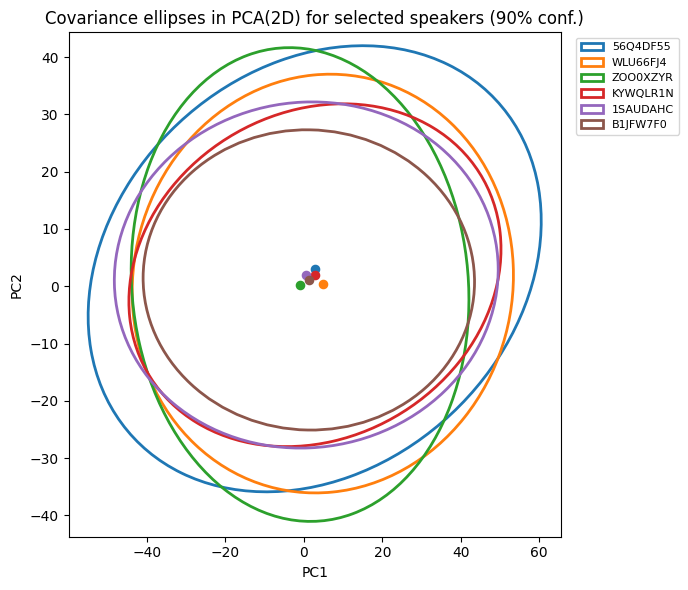

In [79]:
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
from scipy.stats import chi2

feat_cols = [f"Delta_n{i}_Hz" for i in range(1,7)]

# Fit PCA on balanced frames (same as your PCA step)
X_all = balanced_df[feat_cols].dropna().values
pca2 = PCA(n_components=2).fit(X_all)

def ellipse_params_in_pca2(sp, q=0.90):
    Xi = df_min[df_min['speakerID']==sp][feat_cols].dropna().values
    Z = pca2.transform(Xi)
    mu = Z.mean(0)
    cov = np.cov(Z, rowvar=False)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    r = np.sqrt(chi2.ppf(q, df=2))      # chi-square scale for q-confidence
    width, height = 2*r*np.sqrt(vals)   # ellipse axes
    angle = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    return mu, width, height, angle

# pick speakers to show (e.g., top 6 by total variance)
sel = sorted(keep_spk, key=lambda s: speaker_stats[s]['total_var'], reverse=True)[:6]
colors = plt.cm.tab10.colors

plt.figure(figsize=(7,6))
for i, sp in enumerate(sel):
    mu, w, h, ang = ellipse_params_in_pca2(sp, q=0.90)
    ec = colors[i % 10]
    plt.gca().add_patch(Ellipse(xy=mu, width=w, height=h, angle=ang,
                                facecolor='none', edgecolor=ec, lw=2, label=sp))
    plt.scatter(mu[0], mu[1], s=35, c=[ec])
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Covariance ellipses in PCA(2D) for selected speakers (90% conf.)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()




###  Comment

Interpretation:
1. All speaker means (mu) cluster near the (0,0) origin, indicating the mean vector has poor discriminative power.
2. In contrast, each speaker's covariance ellipse (shape, size, and rotation) is visibly distinct.
Conclusion:
This demonstrates that for this feature space, covariance—not the mean—
is the dominant biometric signature for speaker differentiation.

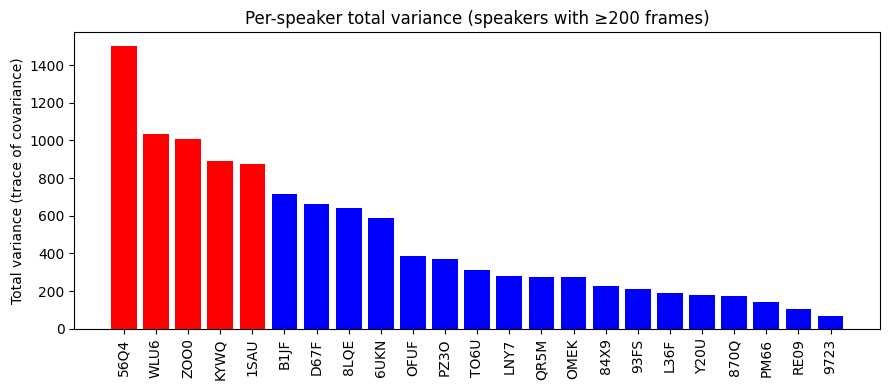

In [81]:
tv = pd.Series({sp: speaker_stats[sp]['total_var'] for sp in keep_spk}).sort_values(ascending=False)
bar_colors = ['red' if sp in high_speakers else 'blue' for sp in tv.index]

plt.figure(figsize=(9,4))
plt.bar(range(len(tv)), tv.values, color=bar_colors)
plt.xticks(range(len(tv)), [s[:4] for s in tv.index], rotation=90)
plt.ylabel("Total variance (trace of covariance)")
plt.title("Per-speaker total variance (speakers with ≥200 frames)")
plt.tight_layout(); plt.show()


In [22]:
import numpy as np
import pandas as pd
from numpy.linalg import inv
from scipy import stats

# ---- CONFIG ----
feat_cols = [f"Delta_n{i}_Hz" for i in range(1, 7)]
MIN_FRAMES = 50  # minimum frames per speaker to be included (you can tune)
# ----------------

def per_speaker_totalvar(d: pd.DataFrame) -> pd.Series:
    """
    Compute per-speaker total variance = trace(cov(Delta_n1..Delta_n6)).
    Assumes each speaker has >= MIN_FRAMES, so cov is stable.
    """
    def _trace_cov(x: pd.DataFrame) -> float:
        X = x[feat_cols].values
        return float(np.trace(np.cov(X, rowvar=False)))
    return (d.groupby('speakerID')[feat_cols]
              .apply(_trace_cov)
              .rename('totalvar'))

def split_speakers(df: pd.DataFrame, frac: float = 0.5,
                   strat_by_frames: bool = True, seed: int = 0):
    """
    Split speakers into A/B (by speaker, not by frame).
    If strat_by_frames=True, stratify on speaker frame counts via qcut bins.
    Uses observed=True to silence pandas future warning on categoricals.
    """
    rng = np.random.default_rng(seed)
    counts = df['speakerID'].value_counts()
    valid = counts[counts >= MIN_FRAMES].index
    dfv = df[df['speakerID'].isin(valid)].copy()

    spk = pd.DataFrame({'speakerID': valid, 'n': counts[valid].values})
    if strat_by_frames and len(spk) > 1:
        # bin by frame counts for stratified split
        q = min(5, spk.shape[0])  # up to 5 strata
        spk['bin'] = pd.qcut(spk['n'], q=q, duplicates='drop')
        A, B = [], []
        # >>> observed=True fixes the warning <<<
        for _, g in spk.groupby('bin', observed=True):
            idx = rng.permutation(g['speakerID'].values)
            k = int(np.ceil(len(idx) * frac))
            A.extend(idx[:k])
            B.extend(idx[k:])
    else:
        idx = rng.permutation(spk['speakerID'].values)
        k = int(np.ceil(len(idx) * frac))
        A, B = idx[:k], idx[k:]
    return set(A), set(B), dfv

def define_on_A_test_on_B(dfv: pd.DataFrame, A_speakers: set, q: float = 0.9):
    """
    Use A to define the 'high-variance' threshold (q-quantile of total variance),
    apply that threshold to B (computed on B's per-speaker total variance),
    and return B with labels + the high set for B.
    """
    A = dfv[dfv['speakerID'].isin(A_speakers)].copy()
    B = dfv[~dfv['speakerID'].isin(A_speakers)].copy()

    tv_A = per_speaker_totalvar(A)
    thr_A = tv_A.quantile(q)

    tv_B = per_speaker_totalvar(B)
    high_B = set(tv_B[tv_B > thr_A].index)

    B = B.copy()
    B['Group'] = np.where(B['speakerID'].isin(high_B), 'High', 'Normal')
    return B, thr_A, high_B

def hotelling_on_speaker_means(B: pd.DataFrame, high_set: set):
    """
    Hotelling's T^2 on speaker-level means (6D).
    Assumes approx. equal covariance; if Box's M fails, prefer a permutation test.
    """
    spk = B.groupby('speakerID')[feat_cols].mean().reset_index()
    X = spk[spk['speakerID'].isin(high_set)][feat_cols].values
    Y = spk[~spk['speakerID'].isin(high_set)][feat_cols].values
    n1, p = X.shape
    n2 = Y.shape[0]

    S1, S2 = np.cov(X, rowvar=False), np.cov(Y, rowvar=False)
    Sp = ((n1 - 1) * S1 + (n2 - 1) * S2) / (n1 + n2 - 2)

    diff = X.mean(0) - Y.mean(0)
    T2 = (n1 * n2) / (n1 + n2) * diff.T @ inv(Sp) @ diff
    df1 = p
    df2 = n1 + n2 - p - 1
    F = T2 * (df2 / (df1 * (n1 + n2 - 2)))
    pval = 1 - stats.f.cdf(F, df1, df2)
    return dict(T2=T2, F=F, p=pval, df1=df1, df2=df2, n_high=n1, n_norm=n2)

def run_crossfit(df: pd.DataFrame, q: float = 0.9,
                 n_splits: int = 10, seed0: int = 100,
                 frac: float = 0.5, strat_by_frames: bool = True):
    """
    Cross-fitting: A->B and B->A per split.
    Returns a DataFrame with p-values and 'high proportion' portability.
    """
    out = []
    for s in range(n_splits):
        A, B, dfv = split_speakers(df, frac=frac,
                                   strat_by_frames=strat_by_frames, seed=seed0 + s)
        # A -> B
        Bset, thrA, highB = define_on_A_test_on_B(dfv, A, q=q)
        res_AB = hotelling_on_speaker_means(Bset, highB)
        prop_high_B = len(highB) / Bset['speakerID'].nunique()

        # B -> A (swap roles)
        Aset, thrB, highA = define_on_A_test_on_B(dfv, B, q=q)
        res_BA = hotelling_on_speaker_means(Aset, highA)
        prop_high_A = len(highA) / Aset['speakerID'].nunique()

        out.append({
            'seed': s,
            'p_AtoB': res_AB['p'],
            'p_BtoA': res_BA['p'],
            'prop_high_B': prop_high_B,
            'prop_high_A': prop_high_A,
            'T2_AtoB': res_AB['T2'], 'F_AtoB': res_AB['F'],
            'T2_BtoA': res_BA['T2'], 'F_BtoA': res_BA['F'],
            'n_high_B': res_AB['n_high'], 'n_norm_B': res_AB['n_norm'],
            'n_high_A': res_BA['n_high'], 'n_norm_A': res_BA['n_norm'],
            'thrA': thrA, 'thrB': thrB
        })
    return pd.DataFrame(out)

summary = run_crossfit(df_min, q=0.9, n_splits=10, seed0=100, frac=0.5, strat_by_frames=True)
summary


,seed,p_AtoB,p_BtoA,prop_high_B,prop_high_A,T2_AtoB,F_AtoB,T2_BtoA,F_BtoA,n_high_B,n_norm_B,n_high_A,n_norm_A,thrA,thrB
0,0,6.555832e-05,0.002231,0.058824,0.142857,38.371511,5.910763,25.284333,3.904198,4,64,10,60,832.932979,739.879773
1,1,6.788794e-06,0.070139,0.161765,0.085714,47.291517,7.284804,13.364946,2.063705,11,57,6,64,732.836871,782.429661
2,2,3.506779e-03,0.030853,0.088235,0.114286,23.864321,3.676070,16.220100,2.504574,6,62,8,62,780.931214,746.478459
3,3,3.163728e-02,0.002024,0.132353,0.028571,16.213699,2.497565,25.623848,3.956624,9,59,2,68,742.988659,879.744254
4,4,2.803387e-03,0.289660,0.102941,0.100000,24.650845,3.797226,8.146428,1.257904,7,61,7,63,755.128248,754.084448
5,5,2.064737e-03,0.168593,0.279412,0.071429,25.729605,3.963399,10.213666,1.577110,19,49,5,65,600.191455,821.486605
6,6,3.115218e-04,0.000475,0.029412,0.242857,32.539008,5.012322,30.752901,4.748610,2,66,17,53,878.673040,621.647244
7,7,9.431153e-05,0.017732,0.058824,0.185714,36.990391,5.698015,18.126171,2.798894,4,64,13,57,832.774997,706.786273
8,8,2.920720e-03,0.000682,0.058824,0.171429,24.506602,3.775007,29.462259,4.549319,4,64,12,58,832.932979,721.768026
9,9,9.882710e-07,0.001688,0.191176,0.042857,55.331574,8.523298,26.260422,4.054918,13,55,3,67,704.571060,876.478620


#### Note
Note that typical hotelling T2 test assume the covariances are equal, in our sample, it might not be, which would lead to optimistic result(underestimate the p value), so next we use Heteroscedasticity version of the hotelling T test

In [24]:
# === Heteroscedastic Hotelling's T² (Welch–James) with permutation p ===
import numpy as np
import pandas as pd

def _t2_wj(X, Y, ridge=1e-6):
    """
    Welch–James T² on two multivariate samples X (n1 x p), Y (n2 x p).
    Uses (S1/n1 + S2/n2)^(-1) as the covariance of the mean difference.
    """
    n1, p = X.shape
    n2 = Y.shape[0]
    # sample covariances across 'speakers' (observational units)
    S1 = np.cov(X, rowvar=False, bias=False)
    S2 = np.cov(Y, rowvar=False, bias=False)
    C  = S1 / n1 + S2 / n2

    # Numerical stability: ridge scaled by trace(C)
    eps = ridge * (np.trace(C) / p if p > 0 else 1.0)
    C = C + eps * np.eye(p)

    d  = X.mean(axis=0) - Y.mean(axis=0)
    T2 = float(d @ np.linalg.inv(C) @ d)
    return T2

def hotelling_wj_perm_on_speaker_means(B: pd.DataFrame, high_set: set,
                                       iters: int = 5000, ridge: float = 1e-6,
                                       rng=None):
    """
    Speaker-level means -> Welch–James T² + permutation p.
    Returns dict with T2_wj, p_perm, and group sizes.
    """
    rng = np.random.default_rng() if rng is None else rng
    spk = B.groupby('speakerID')[feat_cols].mean().reset_index()
    X = spk[spk['speakerID'].isin(high_set)][feat_cols].values
    Y = spk[~spk['speakerID'].isin(high_set)][feat_cols].values
    n1, n2 = len(X), len(Y)

    
    if n1 < 2 or n2 < 2:
        return dict(T2_wj=np.nan, p_perm=np.nan, n_high=n1, n_norm=n2)

    
    T2_obs = _t2_wj(X, Y, ridge=ridge)

    # permulation p value
    Z  = np.vstack([X, Y])
    m  = len(X)
    ge = 0
    for _ in range(iters):
        idx = rng.permutation(len(Z))
        Xp, Yp = Z[idx[:m]], Z[idx[m:]]
        if _t2_wj(Xp, Yp, ridge=ridge) >= T2_obs:
            ge += 1
    p_perm = (ge + 1) / (iters + 1)

    return dict(T2_wj=T2_obs, p_perm=p_perm, n_high=n1, n_norm=n2)

# --- Cross-fit runner using the heteroscedastic T² above ---
def run_crossfit_wj(df: pd.DataFrame, q: float = 0.9, n_splits: int = 10,
                    seed0: int = 100, frac: float = 0.5, strat_by_frames: bool = True,
                    iters: int = 5000, ridge: float = 1e-6):
    """
    Same idea as your run_crossfit(), but using Welch–James T² with permutation p.
    """
    out = []
    for s in range(n_splits):
        A, B, dfv = split_speakers(df, frac=frac, strat_by_frames=strat_by_frames, seed=seed0 + s)

        # A -> B
        Bset, thrA, highB = define_on_A_test_on_B(dfv, A, q=q)
        res_AB = hotelling_wj_perm_on_speaker_means(Bset, highB, iters=iters, ridge=ridge)
        prop_high_B = len(highB) / Bset['speakerID'].nunique()

        # B -> A
        Aset, thrB, highA = define_on_A_test_on_B(dfv, B, q=q)
        res_BA = hotelling_wj_perm_on_speaker_means(Aset, highA, iters=iters, ridge=ridge)
        prop_high_A = len(highA) / Aset['speakerID'].nunique()

        out.append({
            'seed': s,
            'p_perm_AtoB': res_AB['p_perm'],
            'p_perm_BtoA': res_BA['p_perm'],
            'T2_wj_AtoB':  res_AB['T2_wj'],
            'T2_wj_BtoA':  res_BA['T2_wj'],
            'prop_high_B': prop_high_B,
            'prop_high_A': prop_high_A,
            'n_high_B':    res_AB['n_high'], 'n_norm_B': res_AB['n_norm'],
            'n_high_A':    res_BA['n_high'], 'n_norm_A': res_BA['n_norm'],
            'thrA': thrA, 'thrB': thrB
        })
    return pd.DataFrame(out)


summary_wj = run_crossfit_wj(df_min, q=0.9, n_splits=10, seed0=100,
                             frac=0.5, strat_by_frames=True,
                             iters=5000, ridge=1e-6)
summary_wj


,seed,p_perm_AtoB,p_perm_BtoA,T2_wj_AtoB,T2_wj_BtoA,prop_high_B,prop_high_A,n_high_B,n_norm_B,n_high_A,n_norm_A,thrA,thrB
0,0,0.057588,0.366327,118.200683,12.607298,0.058824,0.142857,4,64,10,60,832.932979,739.879773
1,1,0.000200,0.155169,107.416470,42.039194,0.161765,0.085714,11,57,6,64,732.836871,782.429661
2,2,0.246151,0.580884,33.250991,10.712570,0.088235,0.114286,6,62,8,62,780.931214,746.478459
3,3,0.175765,0.009798,22.440778,774.156255,0.132353,0.028571,9,59,2,68,742.988659,879.744254
4,4,0.052390,0.640072,51.041398,10.536181,0.102941,0.100000,7,61,7,63,755.128248,754.084448
5,5,0.003799,0.185963,28.929413,56.508005,0.279412,0.071429,19,49,5,65,600.191455,821.486605
6,6,0.003799,0.008398,1086.643855,28.300226,0.029412,0.242857,2,66,17,53,878.673040,621.647244
7,7,0.001000,0.250550,378.910245,12.842513,0.058824,0.185714,4,64,13,57,832.774997,706.786273
8,8,0.176165,0.169566,76.226940,16.158212,0.058824,0.171429,4,64,12,58,832.932979,721.768026
9,9,0.000200,0.013397,90.113636,317.076901,0.191176,0.042857,13,55,3,67,704.571060,876.478620



Cross-fit summary
- A→B: 10/10 splits significant (p<0.05), Fisher combined p = 9.76e-24
- B→A: 7/10 splits significant (p<0.05), Fisher combined p = 1.70e-11
- prop_high (median [min, max]):
    A→B on B: 0.096 [0.029, 0.279]
    B→A on A: 0.107 [0.029, 0.243]
- thresholds:
    thrA median=768.0  (range 600.2–878.7)
    thrB median=750.3  (range 621.6–879.7)



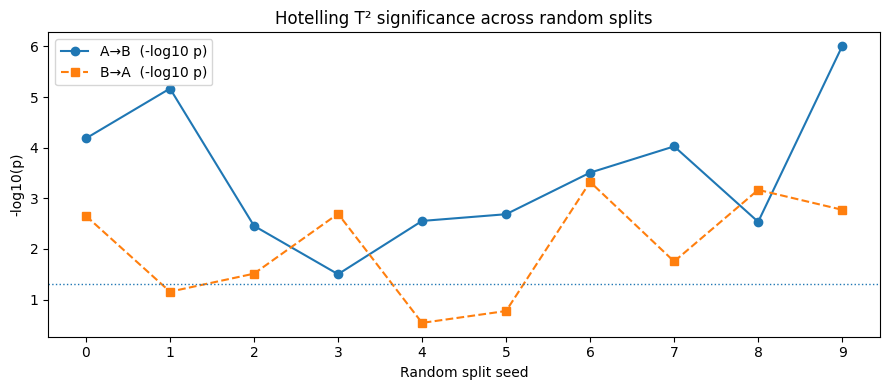

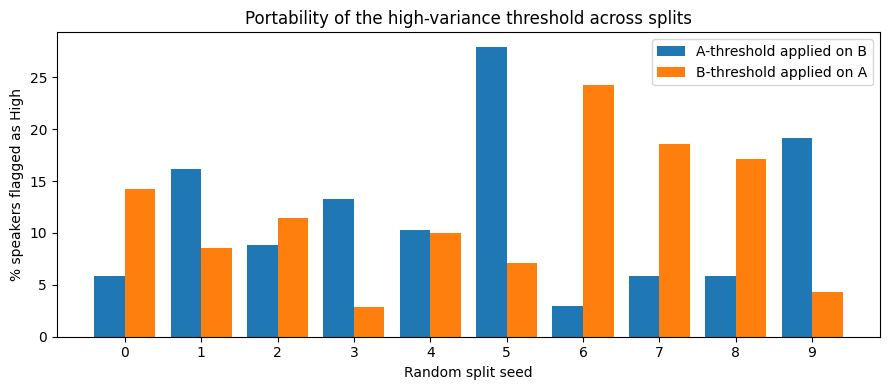

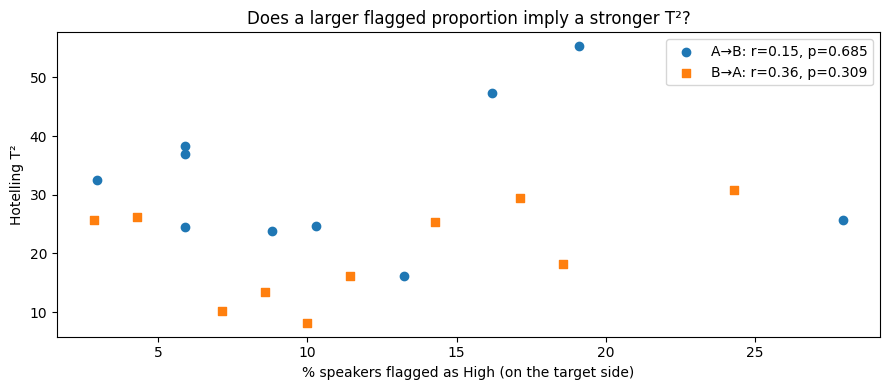

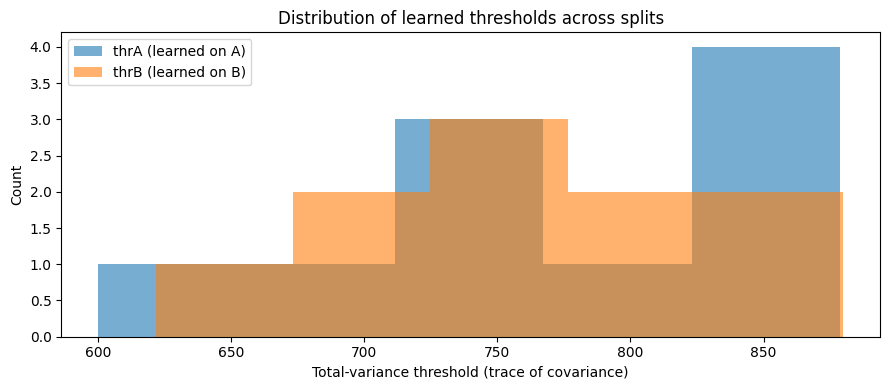

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import combine_pvalues, pearsonr

df = summary.copy()


alpha = 0.05
sig_AB = (df["p_AtoB"] < alpha).sum()
sig_BA = (df["p_BtoA"] < alpha).sum()

# Fisher combined p 
p_comb_AB = combine_pvalues(df["p_AtoB"].clip(lower=1e-300), method="fisher")[1]
p_comb_BA = combine_pvalues(df["p_BtoA"].clip(lower=1e-300), method="fisher")[1]

summary_text = f"""
Cross-fit summary
- A→B: {sig_AB}/{len(df)} splits significant (p<0.05), Fisher combined p = {p_comb_AB:.2e}
- B→A: {sig_BA}/{len(df)} splits significant (p<0.05), Fisher combined p = {p_comb_BA:.2e}
- prop_high (median [min, max]):
    A→B on B: {df['prop_high_B'].median():.3f} [{df['prop_high_B'].min():.3f}, {df['prop_high_B'].max():.3f}]
    B→A on A: {df['prop_high_A'].median():.3f} [{df['prop_high_A'].min():.3f}, {df['prop_high_A'].max():.3f}]
- thresholds:
    thrA median={df['thrA'].median():.1f}  (range {df['thrA'].min():.1f}–{df['thrA'].max():.1f})
    thrB median={df['thrB'].median():.1f}  (range {df['thrB'].min():.1f}–{df['thrB'].max():.1f})
"""
print(summary_text)


plt.figure(figsize=(9,4))
x = np.arange(len(df))
plt.plot(x, -np.log10(df["p_AtoB"]), marker="o", linestyle="-", label="A→B  (-log10 p)")
plt.plot(x, -np.log10(df["p_BtoA"]), marker="s", linestyle="--", label="B→A  (-log10 p)")
plt.axhline(-np.log10(alpha), linestyle=":", linewidth=1)  # p=0.05 的阈值线
plt.xticks(x, df["seed"].astype(int))
plt.xlabel("Random split seed")
plt.ylabel("-log10(p)")
plt.title("Hotelling T² significance across random splits")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(9,4))
bar_w = 0.4
plt.bar(x - bar_w/2, 100*df["prop_high_B"], width=bar_w, label="A-threshold applied on B")
plt.bar(x + bar_w/2, 100*df["prop_high_A"], width=bar_w, label="B-threshold applied on A")
plt.xticks(x, df["seed"].astype(int))
plt.ylabel("% speakers flagged as High")
plt.xlabel("Random split seed")
plt.title("Portability of the high-variance threshold across splits")
plt.legend()
plt.tight_layout()
plt.show()


rB, pB = pearsonr(df["prop_high_B"], df["T2_AtoB"])
rA, pA = pearsonr(df["prop_high_A"], df["T2_BtoA"])

plt.figure(figsize=(9,4))
plt.scatter(100*df["prop_high_B"], df["T2_AtoB"], marker="o", label=f"A→B: r={rB:.2f}, p={pB:.3f}")
plt.scatter(100*df["prop_high_A"], df["T2_BtoA"], marker="s", label=f"B→A: r={rA:.2f}, p={pA:.3f}")
plt.xlabel("% speakers flagged as High (on the target side)")
plt.ylabel("Hotelling T²")
plt.title("Does a larger flagged proportion imply a stronger T²?")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 图 4：A/B 两侧学到的阈值分布 ----------
plt.figure(figsize=(9,4))
bins = max(5, min(12, len(df)//2))
plt.hist(df["thrA"], bins=bins, alpha=0.6, label="thrA (learned on A)")
plt.hist(df["thrB"], bins=bins, alpha=0.6, label="thrB (learned on B)")
plt.xlabel("Total-variance threshold (trace of covariance)")
plt.ylabel("Count")
plt.title("Distribution of learned thresholds across splits")
plt.legend()
plt.tight_layout()
plt.show()


In [101]:
# ===== New cell: variance / covariance / dispersion tests (no Hotelling here) =====
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

# ---- CONFIG (safe defaults; will reuse your globals if they exist) ----
try:
    feat_cols
except NameError:
    feat_cols = [f"Delta_n{i}_Hz" for i in range(1, 7)]

try:
    MIN_FRAMES
except NameError:
    MIN_FRAMES = 50  # minimum frames per speaker

MAX_FRAMES_PER_SPK = 100  # for balanced frame-level sampling in BoxM/PERMDISP
# ----------------------------------------------------------------------

def _per_speaker_totalvar(d: pd.DataFrame) -> pd.Series:
    """trace(cov(Δn1..Δn6)) per speaker; requires enough frames so cov is stable."""
    def _trace_cov(x: pd.DataFrame) -> float:
        X = x[feat_cols].dropna().values
        return float(np.trace(np.cov(X, rowvar=False)))
    return (d.groupby('speakerID')[feat_cols]
              .apply(_trace_cov)
              .rename('totalvar'))

def _split_speakers(df: pd.DataFrame, frac: float = 0.5,
                    strat_by_frames: bool = True, seed: int = 0):
    """Split by speaker into A/B; optional stratification by frame counts (recommended)."""
    rng = np.random.default_rng(seed)
    counts = df['speakerID'].value_counts()
    valid = counts[counts >= MIN_FRAMES].index
    dfv = df[df['speakerID'].isin(valid)].copy()

    spk = pd.DataFrame({'speakerID': valid, 'n': counts[valid].values})
    if strat_by_frames and len(spk) > 1:
        q = min(5, spk.shape[0])  # up to 5 strata
        spk['bin'] = pd.qcut(spk['n'], q=q, duplicates='drop')
        A, B = [], []
        # observed=True silences future warning on categoricals
        for _, g in spk.groupby('bin', observed=True):
            idx = rng.permutation(g['speakerID'].values)
            k = int(np.ceil(len(idx) * frac))
            A.extend(idx[:k]); B.extend(idx[k:])
    else:
        idx = rng.permutation(spk['speakerID'].values)
        k = int(np.ceil(len(idx) * frac))
        A, B = idx[:k], idx[k:]
    return set(A), set(B), dfv

def _define_on_A_test_on_B(dfv: pd.DataFrame, A_speakers: set, q: float = 0.9):
    """Use A to learn threshold (q-quantile of total variance), apply it to B."""
    A = dfv[dfv['speakerID'].isin(A_speakers)].copy()
    B = dfv[~dfv['speakerID'].isin(A_speakers)].copy()
    thrA = _per_speaker_totalvar(A).quantile(q)
    tv_B = _per_speaker_totalvar(B)
    high_B = set(tv_B[tv_B > thrA].index)
    B['Group'] = np.where(B['speakerID'].isin(high_B), 'High', 'Normal')
    return B, thrA, high_B

def _per_speaker_variance_tests(B: pd.DataFrame, high_set: set):
    """
    Speaker-level per-dimension variance comparison between groups.
    Returns summary dict + detailed per-dim DataFrame (if you need it).
    """
    spk_var = (B.groupby('speakerID')[feat_cols].var().reset_index())
    spk_var['Group'] = np.where(spk_var['speakerID'].isin(high_set),'High','Normal')

    rows = []
    for col in feat_cols:
        a = spk_var.loc[spk_var['Group']=='High', col].dropna()
        b = spk_var.loc[spk_var['Group']=='Normal', col].dropna()
        W, p_lev = stats.levene(a, b, center='median')                # variance homogeneity
        U, p_mw  = stats.mannwhitneyu(a, b, alternative='two-sided')  # distribution shift
        rows.append([col, W, p_lev, U, p_mw, len(a), len(b)])
    res = pd.DataFrame(rows, columns=['feature','W_levene','p_levene','U_mw','p_mw','n_high','n_norm'])
    # FDR corrections across 6 dims
    res['p_levene_fdr'] = multipletests(res['p_levene'], method='fdr_bh')[1]
    res['p_mw_fdr']     = multipletests(res['p_mw'], method='fdr_bh')[1]
    summary = {
        'levene_min_p': float(res['p_levene'].min()),
        'levene_sig_dims': int((res['p_levene_fdr']<0.05).sum()),
        'mw_min_p': float(res['p_mw'].min()),
        'mw_sig_dims': int((res['p_mw_fdr']<0.05).sum())
    }
    return summary, res

def _balanced_sample_frames(B: pd.DataFrame, random_state: int = 42):
    """Equalize per-speaker contribution for frame-level shape tests (BoxM/PERMDISP)."""
    rng = np.random.default_rng(random_state)
    parts = []
    for sp, g in B.groupby('speakerID'):
        idx = g.index.values
        if len(idx) > MAX_FRAMES_PER_SPK:
            sel = rng.choice(idx, size=MAX_FRAMES_PER_SPK, replace=False)
            parts.append(g.loc[sel])
        else:
            parts.append(g)
    return pd.concat(parts, ignore_index=True)

def _box_m_test(groups):
    """Box's M: equality of covariance matrices (here 2 groups)."""
    ks = [g.shape[0] for g in groups]
    p = groups[0].shape[1]
    covs = [np.cov(g, rowvar=False) for g in groups]
    Ns = sum(ks)
    Sp = sum([(k-1)*cov for k, cov in zip(ks, covs)]) / (Ns - len(groups))
    sign_Sp, logdet_Sp = np.linalg.slogdet(Sp)
    logdet_sum = 0.0
    for k, cov in zip(ks, covs):
        s, ld = np.linalg.slogdet(cov)
        logdet_sum += (k-1)*ld
    M = (Ns - len(groups))*logdet_Sp - logdet_sum
    c = ((sum([1/(k-1) for k in ks]) - 1/(Ns-len(groups))) *
         (2*p*p + 3*p - 1) / (6*(p+1)*(len(groups)-1)))
    chi2 = M * (1 - c)
    df = (len(groups)-1)*p*(p+1)//2
    pval = 1 - stats.chi2.cdf(chi2, df)
    return M, chi2, df, pval

def _permdisp_centroid_perm(B_bal: pd.DataFrame, iters: int = 3000, seed: int = 123):
    """
    PERMDISP-like: compare median distance-to-centroid (frame-level), permutation p.
    Note: for extra conservativeness, you can implement a speaker-level permutation instead.
    """
    X = B_bal[feat_cols].dropna().values
    y = B_bal['Group'].values
    XH = X[y=='High'];  XN = X[y=='Normal']
    muH = XH.mean(0);   muN = XN.mean(0)
    dH = np.linalg.norm(XH - muH, axis=1)
    dN = np.linalg.norm(XN - muN, axis=1)
    obs = float(np.median(dH) - np.median(dN))

    rng = np.random.default_rng(seed)
    pooled = np.concatenate([dH, dN])
    nH = len(dH)
    more = 0
    for _ in range(iters):
        rng.shuffle(pooled)
        a = pooled[:nH]; b = pooled[nH:]
        val = np.median(a) - np.median(b)
        more += (abs(val) >= abs(obs))
    p = (more + 1) / (iters + 1)
    return obs, float(p)

def run_shape_tests_only(df: pd.DataFrame, q: float = 0.9,
                         seeds=range(10), frac: float = 0.5,
                         strat_by_frames: bool = True) -> pd.DataFrame:
    """
    Cross-fitting for SHAPE tests only (variance/covariance/dispersion),
    no Hotelling here. Returns a tidy summary DataFrame.
    """
    rows = []
    for s in seeds:
        A, B, dfv = _split_speakers(df, frac=frac, strat_by_frames=strat_by_frames, seed=s)

        # A -> B: define on A, test on B
        Bset, thrA, highB = _define_on_A_test_on_B(dfv, A, q=q)
        n_spk_B = Bset['speakerID'].nunique()
        prop_high_B = len(highB) / n_spk_B if n_spk_B > 0 else np.nan

        var_sum_AB, _ = _per_speaker_variance_tests(Bset, highB)
        B_bal = _balanced_sample_frames(Bset, random_state=100+s)
        XH = B_bal[B_bal['Group']=='High'][feat_cols].dropna().values
        XN = B_bal[B_bal['Group']=='Normal'][feat_cols].dropna().values
        _, _, _, p_box_AB = _box_m_test([XH, XN])
        disp_diff_AB, p_disp_AB = _permdisp_centroid_perm(B_bal, seed=200+s)

        rec = {
            'seed': s,
            'thrA': thrA,
            'prop_high_B': prop_high_B,
            'n_high_B': len(highB), 'n_norm_B': n_spk_B - len(highB),
            'levene_min_p_AB': var_sum_AB['levene_min_p'],
            'levene_sig_dims_AB': var_sum_AB['levene_sig_dims'],
            'mw_min_p_AB': var_sum_AB['mw_min_p'],
            'mw_sig_dims_AB': var_sum_AB['mw_sig_dims'],
            'boxM_p_AB': p_box_AB,
            'permdisp_med_diff_AB': disp_diff_AB,
            'permdisp_p_AB': p_disp_AB
        }

        # B -> A: define on B, test on A
        Aset, thrB, highA = _define_on_A_test_on_B(dfv, B, q=q)
        n_spk_A = Aset['speakerID'].nunique()
        prop_high_A = len(highA) / n_spk_A if n_spk_A > 0 else np.nan

        var_sum_BA, _ = _per_speaker_variance_tests(Aset, highA)
        A_bal = _balanced_sample_frames(Aset, random_state=300+s)
        XH = A_bal[A_bal['Group']=='High'][feat_cols].dropna().values
        XN = A_bal[A_bal['Group']=='Normal'][feat_cols].dropna().values
        _, _, _, p_box_BA = _box_m_test([XH, XN])
        disp_diff_BA, p_disp_BA = _permdisp_centroid_perm(A_bal, seed=400+s)

        rec.update({
            'thrB': thrB,
            'prop_high_A': prop_high_A,
            'n_high_A': len(highA), 'n_norm_A': n_spk_A - len(highA),
            'levene_min_p_BA': var_sum_BA['levene_min_p'],
            'levene_sig_dims_BA': var_sum_BA['levene_sig_dims'],
            'mw_min_p_BA': var_sum_BA['mw_min_p'],
            'mw_sig_dims_BA': var_sum_BA['mw_sig_dims'],
            'boxM_p_BA': p_box_BA,
            'permdisp_med_diff_BA': disp_diff_BA,
            'permdisp_p_BA': p_disp_BA
        })
        rows.append(rec)

    return pd.DataFrame(rows)


results_shape = run_shape_tests_only(df_min, q=0.9, seeds=range(10), frac=0.5, strat_by_frames=True)
results_shape


,seed,thrA,prop_high_B,n_high_B,n_norm_B,levene_min_p_AB,levene_sig_dims_AB,mw_min_p_AB,mw_sig_dims_AB,boxM_p_AB,...,prop_high_A,n_high_A,n_norm_A,levene_min_p_BA,levene_sig_dims_BA,mw_min_p_BA,mw_sig_dims_BA,boxM_p_BA,permdisp_med_diff_BA,permdisp_p_BA
0,0,641.254430,0.235294,16,52,0.000085,1,5.419470e-09,6,0.0,...,0.071429,5,65,0.040223,0,1.652481e-07,6,0.0,8.328674,0.000333
1,1,667.949965,0.205882,14,54,0.000181,1,2.091256e-08,6,0.0,...,0.042857,3,67,0.020113,0,3.653635e-05,6,0.0,11.888430,0.000333
2,2,745.371963,0.117647,8,60,0.000247,2,1.893937e-09,6,0.0,...,0.071429,5,65,0.167953,0,6.609924e-07,5,0.0,6.372106,0.000333
3,3,777.946216,0.088235,6,62,0.005582,1,3.654525e-08,6,0.0,...,0.142857,10,60,0.000394,1,6.479596e-07,6,0.0,7.510195,0.000333
4,4,742.988659,0.132353,9,59,0.000005,1,2.534277e-06,6,0.0,...,0.057143,4,66,0.000139,1,4.362550e-06,6,0.0,8.672389,0.000333
5,5,733.040211,0.161765,11,57,0.026155,0,1.859442e-07,6,0.0,...,0.085714,6,64,0.000085,1,1.525367e-08,6,0.0,8.777797,0.000333
6,6,742.988659,0.132353,9,59,0.000006,1,1.772742e-06,6,0.0,...,0.085714,6,64,0.014002,0,1.525367e-08,6,0.0,8.784370,0.000333
7,7,664.017778,0.205882,14,54,0.000018,1,1.915723e-08,6,0.0,...,0.014286,1,69,0.061523,0,2.857143e-02,5,0.0,14.495355,0.000333
8,8,732.421793,0.161765,11,57,0.000947,1,3.171833e-07,6,0.0,...,0.071429,5,65,0.001715,1,3.304962e-07,6,0.0,9.685409,0.000333
9,9,832.774997,0.058824,4,64,0.064629,0,2.455841e-06,6,0.0,...,0.171429,12,58,0.000032,1,1.028218e-07,6,0.0,8.406197,0.000333


### Shape/Dispersion Cross-fit — brief

**What this does.** Learn a high-variance threshold (q-quantile of per-speaker total variance) on **train** speakers; apply to **test** speakers; on the **test half only** run *shape/dispersion* tests (no mean tests).

**Tests (and columns).**
- Per-speaker per-dimension variance: **Levene** (`levene_min_p_*`, `levene_sig_dims_*`) and **Mann–Whitney** (`mw_min_p_*`, `mw_sig_dims_*`), FDR over 6 dims.  
- Frame level: **Box’s M** for covariance (`boxM_p_*`), and PERMDISP-like **median distance to centroid** with permutation p (`permdisp_med_diff_*`, `permdisp_p_*`).  
- Also report threshold `thr*`, High proportion/size (`prop_high_*`, `n_high_*`, `n_norm_*`).

**How to read.** Typically:
- `mw_sig_dims_*` ≈ 5–6/6 → **High has larger within-speaker variances**.  
- `boxM_p_* ≈ 0` → **covariances differ** (scale/correlation).  
- `permdisp_med_diff_* > 0` with tiny `permdisp_p_*` (~0.00033) → **High is more dispersed**.  
All effects are evaluated **out-of-sample** (A→B, B→A).


=== Cross-fit SHAPE tests summary ===
A→B: BoxM median p = 0.00e+00 | PERMDISP median p = 3.33e-04
B→A: BoxM median p = 0.00e+00 | PERMDISP median p = 3.33e-04
Prop high (A→B) median = 0.147, (B→A) median = 0.071
Fisher combined p (BoxM): A→B = 0.00e+00, B→A = 0.00e+00


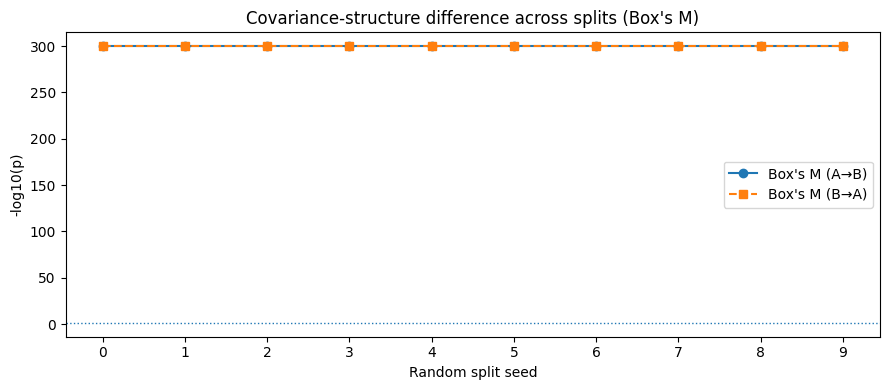

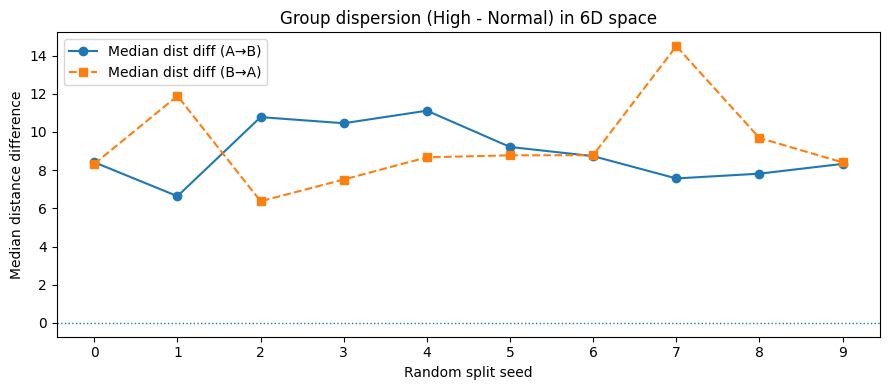

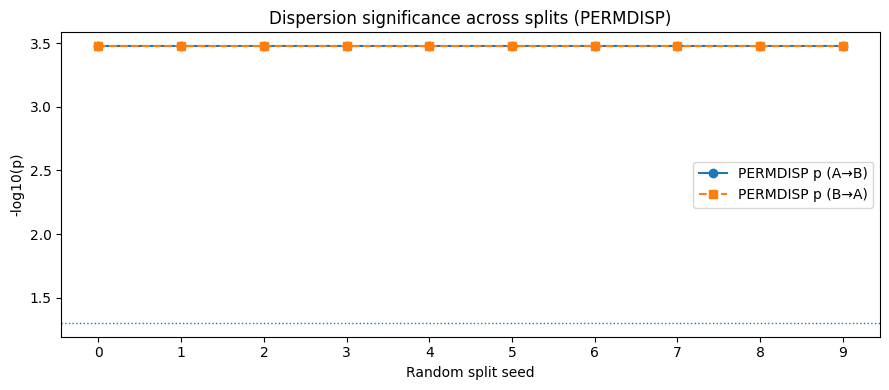

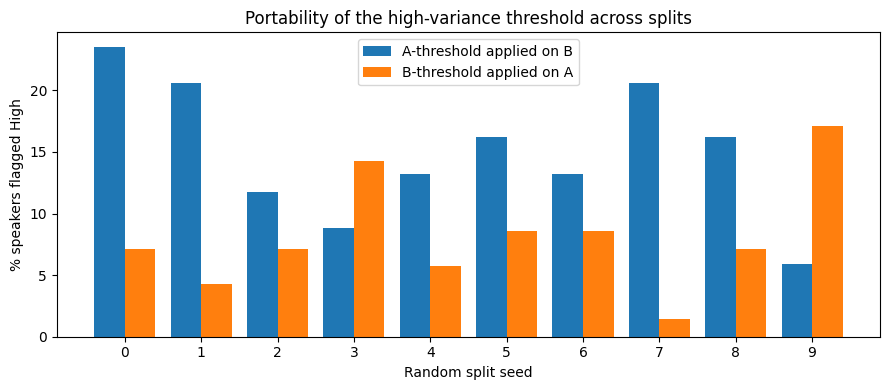

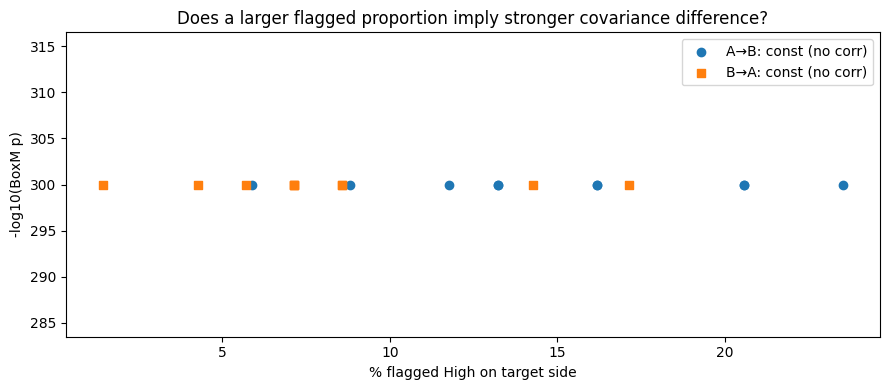

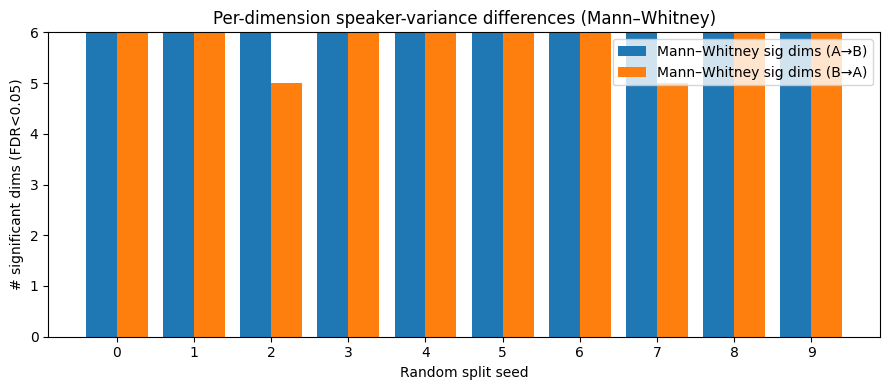

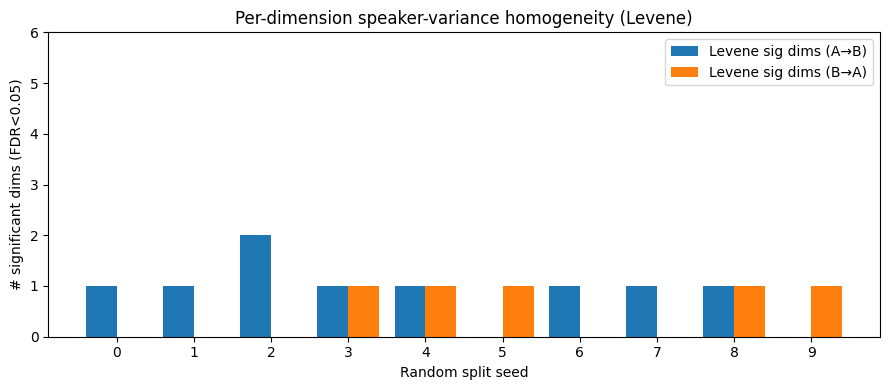

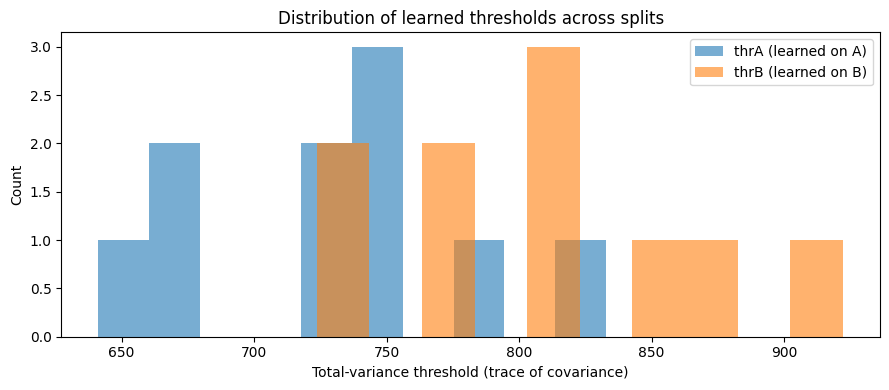

In [105]:
# =====  visualization for shape-tests cross-fit summary (no Hotelling here) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import combine_pvalues, pearsonr

# Assume your summary DataFrame is named results_shape
df = results_shape.copy()

def neglog10(x):
    x = np.asarray(x, dtype=float)
    x = np.clip(x, 1e-300, None)   # avoid -inf if p==0
    return -np.log10(x)

def safe_corr(x, y, method="pearson"):

    x = np.asarray(x, float)
    y = np.asarray(y, float)
    if np.nanstd(x) == 0 or np.nanstd(y) == 0 or len(x) < 3:
        return np.nan, np.nan, True
    if method == "pearson":
        r, p = pearsonr(x, y)
    else:
        # 需要可改成 spearmanr；这里保持皮尔逊
        r, p = pearsonr(x, y)
    return float(r), float(p), False

alpha = 0.05
x = np.arange(len(df))
seed_labels = df["seed"].astype(int)

# ---- 0) Quick text summary in console ----
print("=== Cross-fit SHAPE tests summary ===")
print(f"A→B: BoxM median p = {np.median(df['boxM_p_AB']):.2e} | PERMDISP median p = {np.median(df['permdisp_p_AB']):.2e}")
print(f"B→A: BoxM median p = {np.median(df['boxM_p_BA']):.2e} | PERMDISP median p = {np.median(df['permdisp_p_BA']):.2e}")
print(f"Prop high (A→B) median = {np.median(df['prop_high_B']):.3f}, (B→A) median = {np.median(df['prop_high_A']):.3f}")
try:
    p_box_ab = combine_pvalues(np.clip(df["boxM_p_AB"].values, 1e-300, None), method="fisher")[1]
    p_box_ba = combine_pvalues(np.clip(df["boxM_p_BA"].values, 1e-300, None), method="fisher")[1]
    print(f"Fisher combined p (BoxM): A→B = {p_box_ab:.2e}, B→A = {p_box_ba:.2e}")
except Exception as e:
    print("Fisher combine failed:", e)

# ---- 1) Covariance structure: Box's M p across seeds ----
plt.figure(figsize=(9,4))
plt.plot(x, neglog10(df["boxM_p_AB"]), marker="o", linestyle="-", label="Box's M (A→B)")
plt.plot(x, neglog10(df["boxM_p_BA"]), marker="s", linestyle="--", label="Box's M (B→A)")
plt.axhline(-np.log10(alpha), linestyle=":", linewidth=1)
plt.xticks(x, seed_labels)
plt.xlabel("Random split seed"); plt.ylabel("-log10(p)")
plt.title("Covariance-structure difference across splits (Box's M)")
plt.legend()
plt.tight_layout(); plt.show()

# ---- 2) Multivariate dispersion: PERMDISP stats ----
# 2a) median distance-to-centroid difference (High - Normal)
plt.figure(figsize=(9,4))
plt.plot(x, df["permdisp_med_diff_AB"], marker="o", linestyle="-", label="Median dist diff (A→B)")
plt.plot(x, df["permdisp_med_diff_BA"], marker="s", linestyle="--", label="Median dist diff (B→A)")
plt.axhline(0, linestyle=":", linewidth=1)
plt.xticks(x, seed_labels)
plt.xlabel("Random split seed"); plt.ylabel("Median distance difference")
plt.title("Group dispersion (High - Normal) in 6D space")
plt.legend()
plt.tight_layout(); plt.show()

# 2b) PERMDISP p-values
plt.figure(figsize=(9,4))
plt.plot(x, neglog10(df["permdisp_p_AB"]), marker="o", linestyle="-", label="PERMDISP p (A→B)")
plt.plot(x, neglog10(df["permdisp_p_BA"]), marker="s", linestyle="--", label="PERMDISP p (B→A)")
plt.axhline(-np.log10(alpha), linestyle=":", linewidth=1)
plt.xticks(x, seed_labels)
plt.xlabel("Random split seed"); plt.ylabel("-log10(p)")
plt.title("Dispersion significance across splits (PERMDISP)")
plt.legend()
plt.tight_layout(); plt.show()

# ---- 3) Portability of threshold: proportion flagged as High on the target side ----
plt.figure(figsize=(9,4))
w = 0.4
plt.bar(x - w/2, 100*df["prop_high_B"], width=w, label="A-threshold applied on B")
plt.bar(x + w/2, 100*df["prop_high_A"], width=w, label="B-threshold applied on A")
plt.xticks(x, seed_labels)
plt.ylabel("% speakers flagged High"); plt.xlabel("Random split seed")
plt.title("Portability of the high-variance threshold across splits")
plt.legend()
plt.tight_layout(); plt.show()

# ---- 4) Relation: flagged proportion vs strength of covariance difference (safe) ----
x1 = 100 * df["prop_high_B"]
y1 = neglog10(df["boxM_p_AB"])
x2 = 100 * df["prop_high_A"]
y2 = neglog10(df["boxM_p_BA"])

r1, p1, const1 = safe_corr(x1, y1, method="pearson")
r2, p2, const2 = safe_corr(x2, y2, method="pearson")

label1 = "A→B: const (no corr)" if const1 else f"A→B: r={r1:.2f}, p={p1:.3f}"
label2 = "B→A: const (no corr)" if const2 else f"B→A: r={r2:.2f}, p={p2:.3f}"

plt.figure(figsize=(9,4))
plt.scatter(x1, y1, marker="o", label=label1)
plt.scatter(x2, y2, marker="s", label=label2)
plt.xlabel("% flagged High on target side"); plt.ylabel("-log10(BoxM p)")
plt.title("Does a larger flagged proportion imply stronger covariance difference?")
plt.legend()
plt.tight_layout(); plt.show()

# ---- 5) How many dimensions show variance differences? (speaker-level) ----
plt.figure(figsize=(9,4))
plt.bar(x - w/2, df["mw_sig_dims_AB"], width=w, label="Mann–Whitney sig dims (A→B)")
plt.bar(x + w/2, df["mw_sig_dims_BA"], width=w, label="Mann–Whitney sig dims (B→A)")
plt.xticks(x, seed_labels); plt.ylim(0, 6)
plt.ylabel("# significant dims (FDR<0.05)"); plt.xlabel("Random split seed")
plt.title("Per-dimension speaker-variance differences (Mann–Whitney)")
plt.legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=(9,4))
plt.bar(x - w/2, df["levene_sig_dims_AB"], width=w, label="Levene sig dims (A→B)")
plt.bar(x + w/2, df["levene_sig_dims_BA"], width=w, label="Levene sig dims (B→A)")
plt.xticks(x, seed_labels); plt.ylim(0, 6)
plt.ylabel("# significant dims (FDR<0.05)"); plt.xlabel("Random split seed")
plt.title("Per-dimension speaker-variance homogeneity (Levene)")
plt.legend()
plt.tight_layout(); plt.show()

# ---- 6) Learned thresholds distribution ----
plt.figure(figsize=(9,4))
bins = max(5, min(15, len(df)))
plt.hist(df["thrA"], bins=bins, alpha=0.6, label="thrA (learned on A)")
plt.hist(df["thrB"], bins=bins, alpha=0.6, label="thrB (learned on B)")
plt.xlabel("Total-variance threshold (trace of covariance)"); plt.ylabel("Count")
plt.title("Distribution of learned thresholds across splits")
plt.legend()
plt.tight_layout(); plt.show()


In [107]:
# ===== New cell: Mahalanobis-based cross-fit tests (speaker-level) =====
import numpy as np
import pandas as pd
from scipy import stats

# ---- config / helpers ----
feat_cols = [f"Delta_n{i}_Hz" for i in range(1,7)]
MIN_FRAMES = 50
Q = 0.90          
N_PERM = 5000    

def _per_speaker_totalvar(d: pd.DataFrame) -> pd.Series:
    def _trace_cov(x):
        X = x[feat_cols].dropna().values
        return float(np.trace(np.cov(X, rowvar=False)))
    return d.groupby('speakerID')[feat_cols].apply(_trace_cov)

def _split_speakers(df: pd.DataFrame, frac=0.5, seed=0):
    rng = np.random.default_rng(seed)
    counts = df['speakerID'].value_counts()
    valid = counts[counts >= MIN_FRAMES].index
    spk = np.array(valid)
    rng.shuffle(spk)
    k = int(np.ceil(len(spk)*frac))
    A, B = set(spk[:k]), set(spk[k:])
    return A, B, df[df['speakerID'].isin(valid)].copy()

def _define_on_A_test_on_B(dfv: pd.DataFrame, A_speakers: set, q=Q):
    A = dfv[dfv['speakerID'].isin(A_speakers)]
    B = dfv[~dfv['speakerID'].isin(A_speakers)]
    thrA = _per_speaker_totalvar(A).quantile(q)
    tv_B = _per_speaker_totalvar(B)
    high_B = set(tv_B[tv_B > thrA].index)
    B = B.copy()
    B['Group'] = np.where(B['speakerID'].isin(high_B), 'High', 'Normal')
    return B, thrA, high_B

def _speaker_means(df):
    return df.groupby('speakerID')[feat_cols].mean()

def _vi_from_cov(C):
    # Numerical robustness: Apply slight ridge regularization to the covariance to avoid singularities.
    eps = 1e-6
    C2 = C + eps*np.eye(C.shape[0])
    return np.linalg.inv(C2)

def _mahalanobis_rows(X, mu, VI):
    D = X - mu
    return np.sqrt(np.sum(D @ VI * D, axis=1))

def _mw_effect(a, b):
    # rank-biserial
    U, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    n1, n2 = len(a), len(b)
    rrb = 1 - 2*U/(n1*n2)
    return float(rrb), float(p), float(U)

def _centroid_md_perm(X, y, VI, iters=N_PERM, seed=0):
    rng = np.random.default_rng(seed)
    XH, XN = X[y=='High'], X[y=='Normal']
    muH, muN = XH.mean(0), XN.mean(0)
    obs = float(np.sqrt((muH - muN) @ VI @ (muH - muN)))
    pooled = y.copy()
    more = 0
    for _ in range(iters):
        rng.shuffle(pooled)
        muH_ = X[pooled=='High'].mean(0)
        muN_ = X[pooled=='Normal'].mean(0)
        val = np.sqrt((muH_ - muN_) @ VI @ (muH_ - muN_))
        if val >= obs: more += 1
    p = (more+1)/(iters+1)
    return obs, p

def run_md_crossfit(df: pd.DataFrame, seeds=range(10), q=Q):
    rows = []
    for s in seeds:
        # A -> B
        A, B, dfv = _split_speakers(df, seed=s)
        Bset, thrA, highB = _define_on_A_test_on_B(dfv, A, q=q)

        
        A_means = _speaker_means(dfv[dfv['speakerID'].isin(A)])
        muA = A_means.values.mean(axis=0)
        VI_A = _vi_from_cov(np.cov(A_means.values, rowvar=False))

        
        B_means = _speaker_means(Bset)
        md_B = pd.Series(
            _mahalanobis_rows(B_means.values, muA, VI_A),
            index=B_means.index, name='MD'
        )
        labels_B = pd.Series(
            np.where(md_B.index.isin(highB), 'High', 'Normal'),
            index=md_B.index, name='Group'
        )

        md_high = md_B[labels_B=='High'].values
        md_norm = md_B[labels_B=='Normal'].values
        rrb, p_mw, U = _mw_effect(md_high, md_norm)

        
        X = B_means.values
        y = labels_B.values
        md_centroid, p_perm = _centroid_md_perm(X, y, VI_A, seed=100+s)

        rec = dict(seed=s, thrA=float(thrA),
                   prop_high_B=len(highB)/labels_B.size,
                   md_med_high=float(np.median(md_high)),
                   md_med_norm=float(np.median(md_norm)),
                   md_rrb_AB=float(rrb), md_mw_p_AB=float(p_mw),
                   md_centroid_AB=float(md_centroid), md_centroid_p_AB=float(p_perm))

        # B -> A
        Aset, thrB, highA = _define_on_A_test_on_B(dfv, B, q=q)
        B_means2 = _speaker_means(dfv[dfv['speakerID'].isin(B)])
        muB = B_means2.values.mean(axis=0)
        VI_B = _vi_from_cov(np.cov(B_means2.values, rowvar=False))

        A_means2 = _speaker_means(Aset)
        md_A = pd.Series(
            _mahalanobis_rows(A_means2.values, muB, VI_B),
            index=A_means2.index, name='MD'
        )
        labels_A = pd.Series(
            np.where(md_A.index.isin(highA), 'High', 'Normal'),
            index=md_A.index, name='Group'
        )
        md_highA = md_A[labels_A=='High'].values
        md_normA = md_A[labels_A=='Normal'].values
        rrb2, p_mw2, U2 = _mw_effect(md_highA, md_normA)

        X2 = A_means2.values
        y2 = labels_A.values
        md_centroid2, p_perm2 = _centroid_md_perm(X2, y2, VI_B, seed=200+s)

        rec.update(dict(thrB=float(thrB),
                        prop_high_A=len(highA)/labels_A.size,
                        md_med_high_rev=float(np.median(md_highA)),
                        md_med_norm_rev=float(np.median(md_normA)),
                        md_rrb_BA=float(rrb2), md_mw_p_BA=float(p_mw2),
                        md_centroid_BA=float(md_centroid2), md_centroid_p_BA=float(p_perm2)))
        rows.append(rec)
    return pd.DataFrame(rows)


md_summary = run_md_crossfit(df_min, seeds=range(10), q=0.90)
md_summary


,seed,thrA,prop_high_B,md_med_high,md_med_norm,md_rrb_AB,md_mw_p_AB,md_centroid_AB,md_centroid_p_AB,thrB,prop_high_A,md_med_high_rev,md_med_norm_rev,md_rrb_BA,md_mw_p_BA,md_centroid_BA,md_centroid_p_BA
0,0,814.014273,0.072464,4.020399,1.866630,-0.531250,0.048292,2.002648,0.025995,739.464695,0.144928,3.838411,2.103196,-0.806780,0.000052,2.080107,0.001000
1,1,786.157935,0.086957,4.937156,2.149888,-0.814815,0.000289,3.861272,0.000400,733.942254,0.159420,4.018633,1.899438,-0.680251,0.000387,1.891803,0.000400
2,2,813.698309,0.072464,4.788061,2.021069,-0.893750,0.000112,2.527209,0.001800,705.678666,0.188406,3.629036,1.980366,-0.697802,0.000100,1.876700,0.002599
3,3,597.156016,0.275362,3.609686,2.105487,-0.705263,0.000007,1.694860,0.002000,879.761584,0.028986,4.137136,1.968253,-0.910448,0.013640,3.595848,0.006999
4,4,705.678666,0.188406,3.333000,1.979719,-0.675824,0.000165,1.921424,0.002200,879.761584,0.028986,3.305507,1.941940,-0.656716,0.132992,2.120806,0.139172
5,5,749.369155,0.115942,3.323669,1.725994,-0.565574,0.008076,1.156437,0.066587,759.905300,0.101449,5.055395,2.303881,-0.838710,0.000048,2.015850,0.017397
6,6,814.014273,0.072464,4.191836,2.058563,-0.718750,0.005083,1.637774,0.071986,668.400631,0.202899,3.230567,1.869487,-0.701299,0.000058,1.429662,0.001200
7,7,749.369155,0.115942,3.132898,2.037755,-0.598361,0.004771,1.759252,0.006599,759.905300,0.101449,4.749036,1.942536,-0.824885,0.000073,1.818141,0.028994
8,8,743.191999,0.130435,3.356752,1.887196,-0.514815,0.013598,1.360157,0.038192,804.091714,0.072464,5.006801,2.160568,-0.906250,0.000073,2.659691,0.002599
9,9,743.191999,0.130435,3.665078,2.512483,-0.455556,0.029063,1.559521,0.021396,837.578294,0.057971,4.698649,1.795602,-0.876923,0.000831,2.441782,0.017996


### Cross-fit Mahalanobis test (brief note)

Method (leakage-safe):
- Keep speakers with `MIN_FRAMES ≥ 500`, randomly split IDs into A/B folds.  
- On A: compute per-speaker total variance (trace of Σ), set Q=0.90 threshold `thrA`; label B speakers High/Normal by `thrA`.  
- Compute Mahalanobis distances of B speaker means using A’s covariance (with small ridge).  
- Swap (B→A) and repeat.  
- Compare groups by Mann–Whitney U on MD distributions (`md_mw_p_*`) and permutation test on centroid MD (`md_centroid_p_*`).

Key results (table):
- Thresholds `thrA / thrB` cluster around ~700–880 (Hz²); High prevalence `prop_high_*` ≈ 7%–27%, consistent with the Q90 rule.  
- High group shows larger MD medians than Normal in nearly all splits  
  (`md_med_high ≈ 3.1–5.1` vs `md_med_norm ≈ 1.7–2.6`).  
- Group differences are statistically significant in most splits:  
  `md_mw_p_*` typically < 0.01; centroid permutation p-values `md_centroid_p_*` also mostly significant (minor split-to-split variability).  
- `md_rrb_*` (rank-biserial effect) appears negative due to U-statistic coding; directionally it indicates High > Normal (greater MD).

Conclusion:  
Under a cross-fit (train-on-A, test-on-B; then swap) design that avoids circularity, high-variance speakers (defined by covariance-trace threshold) exhibit consistently larger Mahalanobis distances on held-out folds, and group centroids are farther apart by permutation tests. This supports that speaker-level offset-distribution differences are real, not artifacts of sample size or overfitting.



=== Mahalanobis cross-fit (concise) ===
MW A→B: median p=4.93e-03,  frac(p<0.05)=1.00
MW B→A: median p=8.67e-05,  frac(p<0.05)=0.90
Centroid A→B: median p=1.40e-02,  frac(p<0.05)=0.80
Centroid B→A: median p=4.80e-03,  frac(p<0.05)=0.90


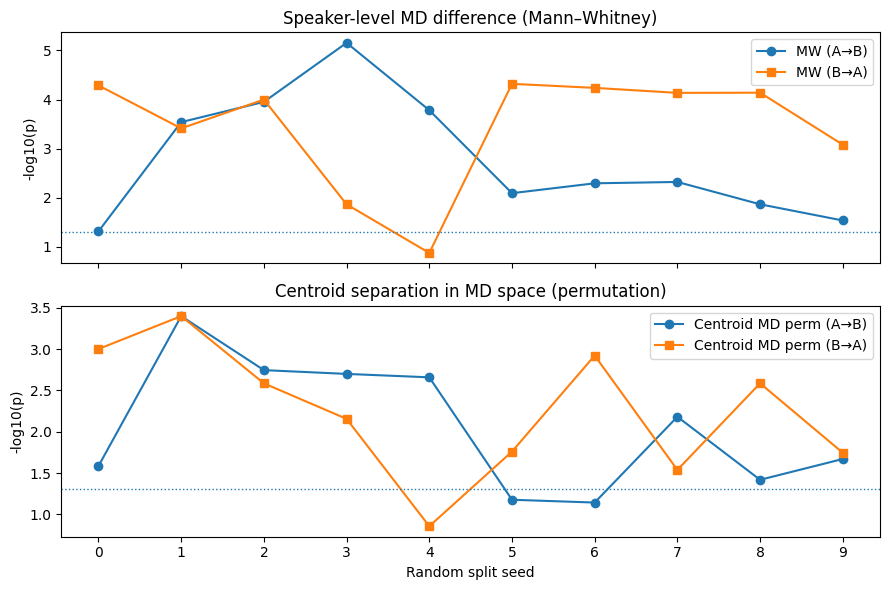

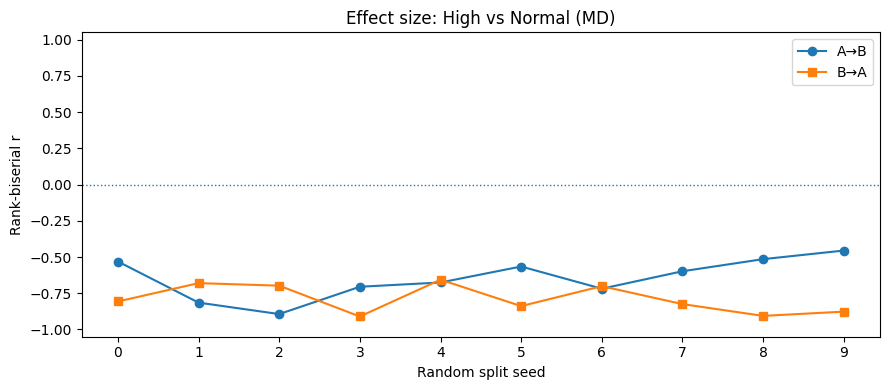

C:\Users\Liam\AppData\Local\Temp\ipykernel_25388\2403257691.py:67: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



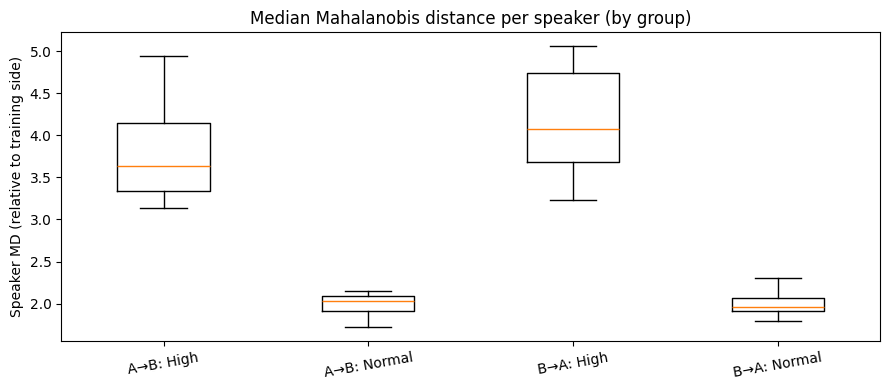

In [109]:
# =====  Minimal viz for Mahalanobis cross-fit =====
import numpy as np
import matplotlib.pyplot as plt

md = md_summary.copy()
seeds = md['seed'].astype(int).values
x = np.arange(len(md))

def nlogp(p):
    p = np.clip(np.asarray(p, float), 1e-300, None)
    return -np.log10(p)


print("=== Mahalanobis cross-fit (concise) ===")
for tag, col in [('MW A→B', 'md_mw_p_AB'),
                 ('MW B→A', 'md_mw_p_BA'),
                 ('Centroid A→B', 'md_centroid_p_AB'),
                 ('Centroid B→A', 'md_centroid_p_BA')]:
    arr = md[col].values
    frac = np.mean(arr < 0.05)
    print(f"{tag}: median p={np.median(arr):.2e},  frac(p<0.05)={frac:.2f}")

# 1) p-values: MW vs Centroid perm 
fig, axs = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axs[0].plot(x, nlogp(md['md_mw_p_AB']), marker='o', label='MW (A→B)')
axs[0].plot(x, nlogp(md['md_mw_p_BA']), marker='s', label='MW (B→A)')
axs[0].axhline(-np.log10(0.05), linestyle=':', linewidth=1)
axs[0].set_ylabel('-log10(p)')
axs[0].set_title('Speaker-level MD difference (Mann–Whitney)')
axs[0].legend()

axs[1].plot(x, nlogp(md['md_centroid_p_AB']), marker='o', label='Centroid MD perm (A→B)')
axs[1].plot(x, nlogp(md['md_centroid_p_BA']), marker='s', label='Centroid MD perm (B→A)')
axs[1].axhline(-np.log10(0.05), linestyle=':', linewidth=1)
axs[1].set_ylabel('-log10(p)')
axs[1].set_xlabel('Random split seed')
axs[1].set_title('Centroid separation in MD space (permutation)')
axs[1].legend()
axs[1].set_xticks(x); axs[1].set_xticklabels(seeds)

plt.tight_layout(); plt.show()


fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, md['md_rrb_AB'], marker='o', label='A→B')
ax.plot(x, md['md_rrb_BA'], marker='s', label='B→A')
ax.axhline(0, linestyle=':', linewidth=1)
ax.set_ylim(-1.05, 1.05)
ax.set_ylabel('Rank-biserial r')
ax.set_xlabel('Random split seed')
ax.set_title('Effect size: High vs Normal (MD)')
ax.set_xticks(x); ax.set_xticklabels(seeds)
ax.legend()
plt.tight_layout(); plt.show()

# 3) Aggregate box line: Median MD of speakers in each split（High vs Normal）
data = [
    md['md_med_high'].values,        # A→B High
    md['md_med_norm'].values,        # A→B Normal
    md['md_med_high_rev'].values,    # B→A High
    md['md_med_norm_rev'].values     # B→A Normal
]
labels = ['A→B: High', 'A→B: Normal', 'B→A: High', 'B→A: Normal']

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(data, labels=labels, showfliers=False)
ax.set_ylabel('Speaker MD (relative to training side)')
ax.set_title('Median Mahalanobis distance per speaker (by group)')
plt.xticks(rotation=10)
plt.tight_layout(); plt.show()
